In [1]:
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from scipy.stats import levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
import glob
import scipy.stats as stats
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
from scipy.stats import anderson, kstest, jarque_bera
from scipy.stats import f

In [5]:
#Visualizacion de filas por grupo
pos = ['tChest', 'tLA', 'tRLA']
datasets = ['50_25', '50_50', '50_75', '100_25', '100_50', '100_75', '150_25', '150_50', '150_75']

for dataset in datasets:
    data = pd.read_csv(f"../data/preprocessed_data/Mhealth_{dataset}.csv")
    data.drop(["Sensor", "ID", "DTS", "Subject"], axis=1, inplace=True)
    y = data["Activity"]
    data.drop("Activity", axis=1, inplace=True)
    X = data[data.columns.to_list()]
    x_train, x_test, y_train , y_test = train_test_split(X,y,test_size=0.3, stratify=y, random_state=0)
    print(f"{dataset} y_test shape:", y_test.shape)
    print(f"{dataset} y_test subsampling shape:", len(y_test) // 10)

50_25 y_test shape: (2680,)
50_25 y_test subsampling shape: 268
50_50 y_test shape: (4054,)
50_50 y_test subsampling shape: 405
50_75 y_test shape: (7800,)
50_75 y_test subsampling shape: 780
100_25 y_test shape: (1340,)
100_25 y_test subsampling shape: 134
100_50 y_test shape: (2008,)
100_50 y_test subsampling shape: 200
100_75 y_test shape: (3982,)
100_75 y_test subsampling shape: 398
150_25 y_test shape: (874,)
150_25 y_test subsampling shape: 87
150_50 y_test shape: (1308,)
150_50 y_test subsampling shape: 130
150_75 y_test shape: (2574,)
150_75 y_test subsampling shape: 257


In [3]:
# Submuestreo sin reemplazo para 10 subgrupos y estratificados
def subsampling(dataset):
    print(f"Subsamplirg to: Mhealth {dataset}")
    data = pd.read_csv(f"../data/preprocessed_data/Mhealth_{dataset}.csv")
    max_depth=pd.read_csv("../data/outputs/md_per_config.csv")

    data.drop(["Sensor", "ID", "DTS", "Subject"], axis=1, inplace=True)

    Y_tChest = data["Activity"]
    Y_tLA = data["Activity"]
    Y_tRLA = data["Activity"]

    data.drop("Activity", axis=1, inplace=True)

    X = data[data.columns.to_list()]

    X_tChest = X.filter(like='tChest')
    X_tLA = X.filter(like='tLA')
    X_tRLA = X.filter(like='tRLA')

    # Dividir en conjunto de entrenamiento y prueba
    x_tChest, X_test_tChest, y_tChest , y_test_tChest = train_test_split(X_tChest,Y_tChest,test_size=0.3, stratify=Y_tChest, random_state=0)
    x_tLA, X_test_tLA, y_tLA , y_test_tLA = train_test_split(X_tLA,Y_tLA,test_size=0.3, stratify=Y_tLA, random_state=0)
    x_tRLA, X_test_tRLA, y_tRLA , y_test_tRLA = train_test_split(X_tRLA,Y_tRLA,test_size=0.3, stratify=Y_tRLA, random_state=0)

    ws_, ov_ = map(int, dataset.split("_"))

    # Obtener max_depth para la configuración específica
    tChest_md = max_depth[(max_depth['pos']=='C') & (max_depth['ws']==ws_) & (max_depth['ov']==ov_)]['md'].values[0]
    tLA_md = max_depth[(max_depth['pos']=='L') & (max_depth['ws']==ws_) & (max_depth['ov']==ov_)]['md'].values[0]
    tRLA_md = max_depth[(max_depth['pos']=='R') & (max_depth['ws']==ws_) & (max_depth['ov']==ov_)]['md'].values[0]

    # Inicializar arrays y listas
    tChest_weighted_f1 = np.zeros(10)  # Array para almacenar f1_score de cada subgrupo
    tLA_weighted_f1 = np.zeros(10)
    tRLA_weighted_f1 = np.zeros(10)

    tChest_remaining_x_test = X_test_tChest.copy()  # Copia del conjunto de prueba
    tLA_remaining_x_test = X_test_tLA.copy()
    tRLA_remaining_x_test = X_test_tRLA.copy()

    tChest_remaining_y_test = y_test_tChest.copy()  # Copia de las etiquetas
    tLA_remaining_y_test = y_test_tLA.copy()
    tRLA_remaining_y_test = y_test_tRLA.copy()

    tChest_n_samples_per_group = len(X_test_tChest) // 10  # Tamaño aproximado de cada subgrupo
    tLA_n_samples_per_group = len(X_test_tLA) // 10
    tRLA_n_samples_per_group = len(X_test_tRLA) // 10

    for i in range(10):
        print(f"Empezando Muestreo {i+1}")

        # Muestreo sin reemplazo y estratificado
        tChest_sample_x_test, tChest_sample_y_test = resample(
            tChest_remaining_x_test, tChest_remaining_y_test,
            replace=False,
            n_samples=tChest_n_samples_per_group,
            stratify=tChest_remaining_y_test,
            random_state=0
        )


        tLA_sample_x_test, tLA_sample_y_test = resample(
            tLA_remaining_x_test, tLA_remaining_y_test,
            replace=False,
            n_samples=tLA_n_samples_per_group,
            stratify=tLA_remaining_y_test,
            random_state=0
        )


        tRLA_sample_x_test, tRLA_sample_y_test = resample(
            tRLA_remaining_x_test, tRLA_remaining_y_test,
            replace=False,
            n_samples=tRLA_n_samples_per_group,
            stratify=tRLA_remaining_y_test,
            random_state=0
        )


        # Entrenar modelo
        tChest_final_model = RandomForestClassifier(max_depth=tChest_md, random_state=0)
        tChest_final_model.fit(x_tChest, y_tChest)

        tLA_final_model = RandomForestClassifier(max_depth=tLA_md, random_state=0)
        tLA_final_model.fit(x_tLA, y_tLA)

        tRLA_final_model = RandomForestClassifier(max_depth=tRLA_md, random_state=0)
        tRLA_final_model.fit(x_tRLA, y_tRLA)

        # Predecir y calcular f1_score ponderado
        tChest_sample_y_test_hat = tChest_final_model.predict(tChest_sample_x_test)
        tChest_weighted_f1[i] = f1_score(tChest_sample_y_test, tChest_sample_y_test_hat, average='weighted')

        tLA_sample_y_test_hat = tLA_final_model.predict(tLA_sample_x_test)
        tLA_weighted_f1[i] = f1_score(tLA_sample_y_test, tLA_sample_y_test_hat, average='weighted')

        tRLA_sample_y_test_hat = tRLA_final_model.predict(tRLA_sample_x_test)
        tRLA_weighted_f1[i] = f1_score(tRLA_sample_y_test, tRLA_sample_y_test_hat, average='weighted')

        # Eliminar los datos usados para asegurar subgrupos disjuntos
        tChest_used_indices = tChest_sample_x_test.index
        tChest_remaining_x_test = tChest_remaining_x_test.drop(tChest_used_indices)
        tChest_remaining_y_test = tChest_remaining_y_test.drop(tChest_used_indices)

        tLA_used_indices = tLA_sample_x_test.index
        tLA_remaining_x_test = tLA_remaining_x_test.drop(tLA_used_indices)
        tLA_remaining_y_test = tLA_remaining_y_test.drop(tLA_used_indices)

        tRLA_used_indices = tRLA_sample_x_test.index
        tRLA_remaining_x_test = tRLA_remaining_x_test.drop(tRLA_used_indices)
        tRLA_remaining_y_test = tRLA_remaining_y_test.drop(tRLA_used_indices)

    # Crear listas para el DataFrame
    tChest_wf1 = tChest_weighted_f1.tolist()
    tChest_md_list = np.repeat([tChest_md], 10).tolist()

    tLA_wf1 = tLA_weighted_f1.tolist()
    tLA_md_list = np.repeat([tLA_md], 10).tolist()

    tRLA_wf1 = tRLA_weighted_f1.tolist()
    tRLA_md_list = np.repeat([tRLA_md], 10).tolist()

    # Crear DataFrame con resultados
    tChest_subsampling_df = pd.DataFrame({
        'dataset': dataset,
        'ws': ws_,
        'ov': ov_,
        'md': tChest_md_list,
        'wf1': tChest_wf1
    })
    tLA_subsampling_df = pd.DataFrame({
        'dataset': dataset,
        'ws': ws_,
        'ov': ov_,
        'md': tLA_md_list,
        'wf1': tLA_wf1
    })
    tRLA_subsampling_df = pd.DataFrame({
        'dataset': dataset,
        'ws': ws_,
        'ov': ov_,
        'md': tRLA_md_list,
        'wf1': tRLA_wf1
    })

    # Guardar resultados en la carpeta resample
    tChest_subsampling_df.to_csv(f"../data/outputs/analysis/Mhealth_{dataset}_tChest.csv")
    tLA_subsampling_df.to_csv(f"../data/outputs/analysis/Mhealth_{dataset}_tLA.csv")
    tRLA_subsampling_df.to_csv(f"../data/outputs/analysis/Mhealth_{dataset}_tRLA.csv")


In [4]:
# Generación de los 10 subgrupos
subsampling('50_25')
subsampling('50_50')
subsampling('50_75')
subsampling('100_25')
subsampling('100_50')
subsampling('100_75')
subsampling('150_25')
subsampling('150_50')
subsampling('150_75')

Subsamplirg to: Mhealth 50_25
Empezando Muestreo 1
Empezando Muestreo 2
Empezando Muestreo 3
Empezando Muestreo 4
Empezando Muestreo 5
Empezando Muestreo 6
Empezando Muestreo 7
Empezando Muestreo 8
Empezando Muestreo 9
Empezando Muestreo 10
Subsamplirg to: Mhealth 50_50
Empezando Muestreo 1
Empezando Muestreo 2
Empezando Muestreo 3
Empezando Muestreo 4
Empezando Muestreo 5
Empezando Muestreo 6
Empezando Muestreo 7
Empezando Muestreo 8
Empezando Muestreo 9
Empezando Muestreo 10
Subsamplirg to: Mhealth 50_75
Empezando Muestreo 1
Empezando Muestreo 2
Empezando Muestreo 3
Empezando Muestreo 4
Empezando Muestreo 5
Empezando Muestreo 6
Empezando Muestreo 7
Empezando Muestreo 8
Empezando Muestreo 9
Empezando Muestreo 10
Subsamplirg to: Mhealth 100_25
Empezando Muestreo 1
Empezando Muestreo 2
Empezando Muestreo 3
Empezando Muestreo 4
Empezando Muestreo 5
Empezando Muestreo 6
Empezando Muestreo 7
Empezando Muestreo 8
Empezando Muestreo 9
Empezando Muestreo 10
Subsamplirg to: Mhealth 100_50
Empe

In [7]:
# Unir archivos
files = glob.glob("../data/outputs/analysis/Mhealth_*_*.csv")
all_results = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Guardar un CSV maestro
all_results.to_csv("../data/outputs/analysis/Mhealth_results.csv", index=False)


In [18]:
# Cargar el archivo CSV
data = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")
data["ws"] = data["ws"].astype("category")
data["ov"] = data["ov"].astype("category")
data["dataset"] = data["dataset"].astype("category")  # combinaciones WS_OV

# Verificar valores únicos
print("window size:", data['ws'].unique())
print("overlapping:", data['ov'].unique())
print("Combinaciones:", data['dataset'].unique())

# --- ANOVA por WS ---
print("\nANOVA por WS:")
model_ws = ols('wf1 ~ C(ws)', data=data).fit()
anova_ws = sm.stats.anova_lm(model_ws, typ=2)
print(anova_ws)

# --- ANOVA por OV ---
print("\nANOVA por OV:")
model_ov = ols('wf1 ~ C(ov)', data=data).fit()
anova_ov = sm.stats.anova_lm(model_ov, typ=2)
print(anova_ov)

# --- ANOVA por combinación WS_OV ---
print("\nANOVA por combinación WS_OV:")
model_wsov = ols('wf1 ~ C(dataset)', data=data).fit()
anova_wsov = sm.stats.anova_lm(model_wsov, typ=2)
print(anova_wsov)

# --- ANOVA factorial WS x OV ---
print("\nANOVA factorial WS x OV:")
model_factorial = ols('wf1 ~ C(ws) * C(ov)', data=data).fit()
anova_factorial = sm.stats.anova_lm(model_factorial, typ=2)
print(anova_factorial)


window size: [100, 150, 50]
Categories (3, int64): [50, 100, 150]
overlapping: [25, 50, 75]
Categories (3, int64): [25, 50, 75]
Combinaciones: ['100_25', '100_50', '100_75', '150_25', '150_50', '150_75', '50_25', '50_50', '50_75']
Categories (9, object): ['100_25', '100_50', '100_75', '150_25', ..., '150_75', '50_25', '50_50', '50_75']

ANOVA por WS:
            sum_sq     df          F        PR(>F)
C(ws)     0.059000    2.0  15.607377  3.887004e-07
Residual  0.504668  267.0        NaN           NaN

ANOVA por OV:
            sum_sq     df         F    PR(>F)
C(ov)     0.002997    2.0  0.713696  0.490762
Residual  0.560671  267.0       NaN       NaN

ANOVA por combinación WS_OV:
              sum_sq     df         F    PR(>F)
C(dataset)  0.066256    8.0  4.345672  0.000061
Residual    0.497413  261.0       NaN       NaN

ANOVA factorial WS x OV:
               sum_sq     df          F        PR(>F)
C(ws)        0.059000    2.0  15.479187  4.438172e-07
C(ov)        0.002997    2.0   0.

In [16]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Cargar el archivo CSV
data = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")
data["ws"] = data["ws"].astype("category")
data["ov"] = data["ov"].astype("category")
data["dataset"] = data["dataset"].astype("category")  # combinaciones WS_OV

# Verificar valores únicos
print("window size:", data['ws'].unique())
print("overlapping:", data['ov'].unique())
print("Combinaciones:", data['dataset'].unique())

# --- ANOVA factorial WS x OV ---
print("\nANOVA factorial WS x OV:")
model_factorial = ols('wf1 ~ C(ws) * C(ov)', data=data).fit()
anova_factorial = sm.stats.anova_lm(model_factorial, typ=2)
print(anova_factorial)

# --- Guardar residuos en archivo CSV ---
residuos = pd.DataFrame({
    "residuos": model_factorial.resid,
    "ajustados": model_factorial.fittedvalues,
    "ws": data["ws"],
    "ov": data["ov"],
    "dataset": data["dataset"]
})

# Guardar en archivo
output_path = "../data/outputs/analysis/residuos_anova_factorial.csv"
residuos.to_csv(output_path, index=False)

print(f"\n✅ Residuos guardados correctamente en: {output_path}")
print(residuos.head())


window size: [100, 150, 50]
Categories (3, int64): [50, 100, 150]
overlapping: [25, 50, 75]
Categories (3, int64): [25, 50, 75]
Combinaciones: ['100_25', '100_50', '100_75', '150_25', '150_50', '150_75', '50_25', '50_50', '50_75']
Categories (9, object): ['100_25', '100_50', '100_75', '150_25', ..., '150_75', '50_25', '50_50', '50_75']

ANOVA factorial WS x OV:
               sum_sq     df          F        PR(>F)
C(ws)        0.059000    2.0  15.479187  4.438172e-07
C(ov)        0.002997    2.0   0.786382  4.565658e-01
C(ws):C(ov)  0.004258    4.0   0.558560  6.929499e-01
Residual     0.497413  261.0        NaN           NaN

✅ Residuos guardados correctamente en: ../data/outputs/analysis/residuos_anova_factorial.csv
   residuos  ajustados   ws  ov dataset
0 -0.030796    0.88345  100  25  100_25
1  0.001949    0.88345  100  25  100_25
2 -0.022880    0.88345  100  25  100_25
3 -0.030290    0.88345  100  25  100_25
4 -0.043662    0.88345  100  25  100_25



✅ Resultados guardados en: ../data/outputs/analysis/normalidad_residuos_anova_factorial.csv

Tabla de resultados de normalidad sobre los residuos:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H₀ (no normal)
  Anderson-Darling         5.377534                     0.776      NaN                        Sí
Kolmogorov-Smirnov         0.116254                     0.134 0.001232                        Sí
       Jarque-Bera        13.866517                     5.990 0.000975                        Sí


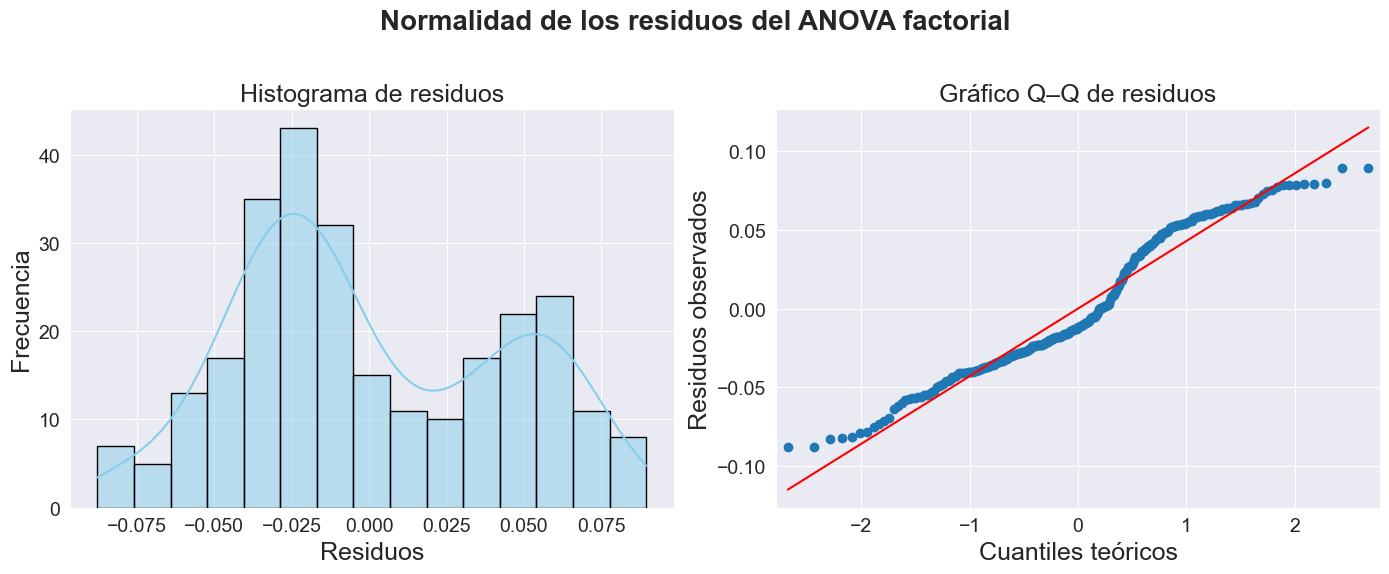

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import anderson, kstest, jarque_bera
import statsmodels.api as sm

# -------------------------------
# Análisis de normalidad de residuos del ANOVA factorial
# -------------------------------
def normalidad_residuos_anova():
    """
    Evalúa la normalidad de los residuos del ANOVA factorial mediante
    Anderson-Darling, Kolmogorov-Smirnov y Jarque-Bera.
    Genera tabla, guarda resultados en CSV y crea gráficos (histograma + Q–Q plot).
    """

    # Leer archivo de residuos
    df = pd.read_csv("../data/outputs/analysis/residuos_anova_factorial.csv")
    residuos = df["residuos"].dropna()

    # --- 1. Anderson–Darling ---
    result_ad = anderson(residuos)
    ad_statistic = result_ad.statistic
    ad_critical_value = result_ad.critical_values[2]  # 5%
    ad_p_value = np.nan  # no disponible
    ad_reject = "Sí" if ad_statistic > ad_critical_value else "No"

    # --- 2. Kolmogorov–Smirnov ---
    stat_ks, p_ks = kstest(residuos, 'norm', args=(residuos.mean(), residuos.std()))
    ks_reject = "Sí" if p_ks < 0.05 else "No"

    # --- 3. Jarque–Bera ---
    stat_jb, p_jb = jarque_bera(residuos)
    jb_reject = "Sí" if p_jb < 0.05 else "No"

    # --- Crear tabla resumen ---
    table = pd.DataFrame({
        'Prueba': ['Anderson-Darling', 'Kolmogorov-Smirnov', 'Jarque-Bera'],
        'Estadístico (e)': [ad_statistic, stat_ks, stat_jb],
        'Valor crítico al 5% (vc)': [ad_critical_value, 0.134, 5.99],
        'P-valor': [ad_p_value, p_ks, p_jb],
        'Rechazo de H₀ (no normal)': [ad_reject, ks_reject, jb_reject]
    })

    # Guardar resultados
    output_csv = "../data/outputs/analysis/normalidad_residuos_anova_factorial.csv"
    table.to_csv(output_csv, index=False)
    print(f"\n✅ Resultados guardados en: {output_csv}\n")
    print("Tabla de resultados de normalidad sobre los residuos:")
    print(table.to_string(index=False))

    # --- Gráficos: Histograma + Q–Q Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Histograma con KDE
    sns.histplot(residuos, bins=15, kde=True, color="skyblue", edgecolor="black", ax=axes[0])
    axes[0].set_title("Histograma de residuos", fontsize=18)
    axes[0].set_xlabel("Residuos", fontsize=18)
    axes[0].set_ylabel("Frecuencia", fontsize=18)
    axes[0].tick_params(axis='both', labelsize=14)

    # Q–Q plot
    sm.qqplot(residuos, line='s', ax=axes[1])
    axes[1].set_title("Gráfico Q–Q de residuos", fontsize=18)
    axes[1].set_xlabel("Cuantiles teóricos", fontsize=18)
    axes[1].set_ylabel("Residuos observados", fontsize=18)
    axes[1].tick_params(axis='both', labelsize=14)

    # Título principal
    fig.suptitle("Normalidad de los residuos del ANOVA factorial", fontsize=20, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("../data/outputs/imgs/normalidad_residuos_anova_factorial.png", dpi=300, bbox_inches='tight')
    plt.show()


# -------------------------------
# Ejecutar la función
# -------------------------------
normalidad_residuos_anova()


In [2]:
#Test de comparaciones para dos muestras independientes (t-student-con varianzas desiguales)
def t_student(grupo):
    df = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")

    # Obtener sensores únicos y ordenarlos para consistencia
    categorias = sorted(df[grupo].unique())

    # Nivel de significancia original
    alpha = 0.05

    # Crear combinaciones par a par
    comparaciones = list(itertools.combinations(categorias, 2))

    # Número de comparaciones para Holm-Bonferroni
    num_comparaciones = len(comparaciones)

    # Calcular alfa corregido inicial (para referencia)
    alfa_corregido_inicial = alpha / num_comparaciones

    # Lista para resultados iniciales
    resultados_iniciales = []

    # Para cada par de sensores, calcular p-valor inicial
    for cat1, cat2 in comparaciones:
        grupo1 = df[df[grupo] == cat1]['wf1'].dropna()
        grupo2 = df[df[grupo] == cat2]['wf1'].dropna()

        if not grupo1.empty and not grupo2.empty:
            # Calcular cuasi desviación estándar (desviación estándar muestral, ddof=1)
            std1 = np.std(grupo1, ddof=1)  # División por n-1
            std2 = np.std(grupo2, ddof=1)  # División por n-1

            # Calcular ratio: cuasi desviación mayor / cuasi desviación menor
            if std1 == 0 or std2 == 0:
                ratio_std = np.nan
            else:
                ratio_std = max(std1, std2) / min(std1, std2)

            # Determinar equal_var basado en el ratio
            if np.isnan(ratio_std) or ratio_std >= 2:
                equal_var = False  # Varianzas desiguales (Welch's t-test)
            else:
                equal_var = True   # Varianzas iguales (t-test estándar)

            # Prueba t de Student para muestras independientes con equal_var dinámico
            stat, p_value = ttest_ind(grupo1, grupo2, equal_var=equal_var, alternative='two-sided')

            # Clasificación de varianzas basada en el ratio
            if np.isnan(ratio_std):
                clasificacion_varianzas = "Indefinido"
            elif ratio_std < 2:
                clasificacion_varianzas = "Varianzas iguales"
            else:
                clasificacion_varianzas = "Varianza diferente"

            promedio1 = round(grupo1.mean(), 3)
            promedio2 = round(grupo2.mean(), 3)

            # Almacenar resultados iniciales con p_value original
            resultados_iniciales.append([cat1, promedio1, cat2, promedio2, round(p_value, 7), round(p_value, 7), round(alfa_corregido_inicial, 7), round(ratio_std, 7), clasificacion_varianzas])

    # Extraer p-valores para la corrección de Holm
    p_valores = [item[4] for item in resultados_iniciales]

    # Aplicar corrección de Holm-Bonferroni con multipletests
    reject, pvals_holm, _, _ = multipletests(p_valores, alpha=alpha, method="holm")

    # Asignar p-valores ajustados y determinar diferencia significativa
    resultados_finales = []
    for i, resultado in enumerate(resultados_iniciales):
        cat1, promedio1, cat2, promedio2, p_value, _, alfa_corregido, ratio_std, clasificacion_varianzas = resultado
        p_holm_ajustado = round(pvals_holm[i], 7)
        diferencia_significativa = "Sí" if reject[i] else "No"  # Usar reject para determinar significancia
        resultados_finales.append([
            cat1, promedio1, cat2, promedio2,
            round(p_value, 7), p_holm_ajustado,
            round(alfa_corregido, 7), round(ratio_std, 7),
            diferencia_significativa, clasificacion_varianzas
        ])

    # Crear DataFrame con los resultados
    df_resultados = pd.DataFrame(resultados_finales, columns=[
        'Categoria 1', 'Promedio 1', 'Categoria 2', 'Promedio 2',
        'p-valor', 'P-valor Holm-Bonferroni', 'Alfa corregido',
        'ratio',
        'Diff significativa', 'Clasificación de varianzas'
    ])

    # Mostrar la tabla
    print("\nTabla de Comparaciones Par a Par:")
    print(df_resultados)

    # Guardar la tabla en un archivo CSV en la ruta especificada
    df_resultados.to_csv(f"../data/outputs/tabla_comparacion_{grupo}.csv", index=False)
    print(f"\nLa tabla se guardó como tabla_comparacion_{grupo}.")

In [3]:
t_student('ws')


Tabla de Comparaciones Par a Par:
   Categoria 1  Promedio 1  Categoria 2  Promedio 2       p-valor  \
0           50       0.852          100       0.885  1.000000e-07   
1           50       0.852          150       0.882  3.520000e-05   
2          100       0.885          150       0.882  7.019689e-01   

   P-valor Holm-Bonferroni  Alfa corregido     ratio Diff significativa  \
0             3.000000e-07        0.016667  1.239040                 Sí   
1             7.040000e-05        0.016667  1.229640                 Sí   
2             7.019689e-01        0.016667  1.523573                 No   

  Clasificación de varianzas  
0          Varianzas iguales  
1          Varianzas iguales  
2          Varianzas iguales  

La tabla se guardó como tabla_comparacion_ws.


In [4]:
t_student('ov')


Tabla de Comparaciones Par a Par:
   Categoria 1  Promedio 1  Categoria 2  Promedio 2   p-valor  \
0           25       0.869           50       0.877  0.235599   
1           25       0.869           75       0.873  0.575782   
2           50       0.877           75       0.873  0.523583   

   P-valor Holm-Bonferroni  Alfa corregido     ratio Diff significativa  \
0                 0.706797        0.016667  1.129396                 No   
1                 1.000000        0.016667  1.070720                 No   
2                 1.000000        0.016667  1.054801                 No   

  Clasificación de varianzas  
0          Varianzas iguales  
1          Varianzas iguales  
2          Varianzas iguales  

La tabla se guardó como tabla_comparacion_ov.


In [5]:
t_student('dataset')


Tabla de Comparaciones Par a Par:
   Categoria 1  Promedio 1 Categoria 2  Promedio 2   p-valor  \
0       100_25       0.883      100_50       0.886  0.807537   
1       100_25       0.883      100_75       0.886  0.804896   
2       100_25       0.883      150_25       0.875  0.509038   
3       100_25       0.883      150_50       0.894  0.267471   
4       100_25       0.883      150_75       0.878  0.633878   
5       100_25       0.883       50_25       0.849  0.001265   
6       100_25       0.883       50_50       0.852  0.003185   
7       100_25       0.883       50_75       0.856  0.006560   
8       100_50       0.886      100_75       0.886  0.995600   
9       100_50       0.886      150_25       0.875  0.404618   
10      100_50       0.886      150_50       0.894  0.373173   
11      100_50       0.886      150_75       0.878  0.508958   
12      100_50       0.886       50_25       0.849  0.000633   
13      100_50       0.886       50_50       0.852  0.001653   
14   

In [6]:
#Homocedasticidad
def homocedasticidad(grupo):
    df = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")

    grupos = df.groupby(grupo)['wf1'].apply(list)
    print(f"\nGrupos evaluados ({grupo}): {list(grupos.index)}")
    print(f"Número de grupos: {len(grupos)}")

    # Preparar los datos como listas independientes
    listas_de_datos = [grupo for grupo in grupos if len(grupo) > 0]

    # Verificar que haya al menos 2 grupos
    if len(listas_de_datos) >= 2:
        # Ejecutar prueba de Levene (Brown–Forsythe usando medianas)
        stat, p_value = levene(*listas_de_datos, center='median')  # global Levene test

        # Calcular grados de libertad
        k = len(listas_de_datos)  # número de grupos
        n_total = sum([len(g) for g in listas_de_datos])  # tamaño total de la muestra
        df1 = k - 1
        df2 = n_total - k

        # Mostrar resultado general
        print(f"\nPrueba de Levene (Brown–Forsythe) para '{grupo}':")
        if p_value > 0.05:
            print("✅ No se rechaza H₀: Se asume homocedasticidad (igualdad de varianzas entre grupos)")
        else:
            print("❌ Se rechaza H₀: Hay evidencia de heterocedasticidad (varianzas diferentes)")

        # Tabla resumen de resultados
        tabla = pd.DataFrame({
            'F': [round(stat, 4)],
            'df1': [df1],
            'df2': [df2],
            'Significance': [round(p_value, 5)]
        })

        print("\nLevel test of variance equality (Levene - Brown-Forsythe):\n")
        print(tabla.to_string(index=False))

    else:
        print("❗ Datos insuficientes para evaluar homocedasticidad global")

In [7]:
homocedasticidad('ws')


Grupos evaluados (ws): [50, 100, 150]
Número de grupos: 3

Prueba de Levene (Brown–Forsythe) para 'ws':
❌ Se rechaza H₀: Hay evidencia de heterocedasticidad (varianzas diferentes)

Level test of variance equality (Levene - Brown-Forsythe):

     F  df1  df2  Significance
7.8761    2  267       0.00047


In [8]:
homocedasticidad('ov')


Grupos evaluados (ov): [25, 50, 75]
Número de grupos: 3

Prueba de Levene (Brown–Forsythe) para 'ov':
✅ No se rechaza H₀: Se asume homocedasticidad (igualdad de varianzas entre grupos)

Level test of variance equality (Levene - Brown-Forsythe):

     F  df1  df2  Significance
0.8789    2  267       0.41645


In [9]:
homocedasticidad('dataset')


Grupos evaluados (dataset): ['100_25', '100_50', '100_75', '150_25', '150_50', '150_75', '50_25', '50_50', '50_75']
Número de grupos: 9

Prueba de Levene (Brown–Forsythe) para 'dataset':
❌ Se rechaza H₀: Hay evidencia de heterocedasticidad (varianzas diferentes)

Level test of variance equality (Levene - Brown-Forsythe):

     F  df1  df2  Significance
2.7408    8  261       0.00641


In [10]:
#Prueba no parametrica
#PRUEBA  DE KRUSKAL-WALLIS
def kruskal(grupo):
    df = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")
    alpha = 0.05

    df[grupo] = df[grupo].astype("category")

    print(f"\nKruskal-Wallis para {grupo}:")

    grupos = df.groupby(grupo)['wf1'].apply(list)
    stat, p_value = stats.kruskal(*grupos)

    print(f"Estadístico: {stat}, p-valor: {p_value}")

    if p_value < alpha:
        print(f"❌ Rechazamos H₀: diferencias significativas entre ventanas ({grupo}).")
    else:
        print(f"✅ No hay diferencias significativas entre ventanas ({grupo}).")

In [11]:
kruskal('ws')


Kruskal-Wallis para ws:
Estadístico: 31.549815498155, p-valor: 1.4094335722656113e-07
❌ Rechazamos H₀: diferencias significativas entre ventanas (ws).


C:\Users\nathan\AppData\Local\Temp\ipykernel_32480\1620818968.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos = df.groupby(grupo)['wf1'].apply(list)


In [21]:
kruskal('ov')


Kruskal-Wallis para ov:
Estadístico: 1.3237009703429976, p-valor: 0.515895793141574
✅ No hay diferencias significativas entre ventanas (ov).


C:\Users\nathan\AppData\Local\Temp\ipykernel_41852\1620818968.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos = df.groupby(grupo)['wf1'].apply(list)


In [22]:
kruskal('dataset')


Kruskal-Wallis para dataset:
Estadístico: 35.15688943556097, p-valor: 2.503502126042733e-05
❌ Rechazamos H₀: diferencias significativas entre ventanas (dataset).


C:\Users\nathan\AppData\Local\Temp\ipykernel_41852\1620818968.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos = df.groupby(grupo)['wf1'].apply(list)


In [11]:
#PRUEBA NO PARAMETRICA U de Mann-Whitney con holm-bonferroni
def mann_whitney_holm(grupo):
    df = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")

    # Definir el nivel de significancia original
    alpha_original = 0.05

    # Asegurar que el grupo sea categórico
    df[grupo] = df[grupo].astype("category")

    # --- Ordenar categorías si los valores del grupo tienen formato "a_b" ---
    if df[grupo].dtype == "object" or pd.api.types.is_categorical_dtype(df[grupo]):
        if "_" in str(df[grupo].iloc[0]):  # solo si realmente hay "_"
            # Separar en dos partes y convertir a número
            orden_categorias = sorted(
                df[grupo].unique(),
                key=lambda x: (int(x.split("_")[0]), int(x.split("_")[1]))
            )
            # Redefinir el orden categórico
            df[grupo] = pd.Categorical(df[grupo], categories=orden_categorias, ordered=True)


    # Obtener la lista de grupos unicos
    categorias = df[grupo].unique()

    # Crear todas las combinaciones posibles de comparación
    comparaciones = list(itertools.combinations(categorias, 2))

    # Crear una matriz vacía para los p-valores
    p_matrix = pd.DataFrame(np.ones((len(categorias), len(categorias))), index=categorias, columns=categorias)

    # Lista para almacenar p-valores iniciales
    p_valores = []

    # Prueba de U Mann-Whitney para cada par
    for cat1, cat2 in comparaciones:
        grupo1 = df[df[grupo] == cat1]["wf1"]
        grupo2 = df[df[grupo] == cat2]["wf1"]

        # Prueba de Mann-Whitney
        stat, p_value = stats.mannwhitneyu(grupo1, grupo2, alternative="two-sided")

        # Almacenar el p-valor en la matriz
        p_matrix.loc[cat1, cat2] = p_value
        p_matrix.loc[cat2, cat1] = p_value  # Para que la matriz sea simétrica

        # Almacenar p-valor para la corrección
        p_valores.append(round(p_value, 7))

    # Aplicar corrección de Holm-Bonferroni con multipletests
    reject, pvals_holm, _, _ = multipletests(p_valores, alpha=alpha_original, method="holm")

    # Lista para almacenar resultados detallados
    resultados = []

    # Asignar resultados con p-valores ajustados
    for i, (cat1, cat2) in enumerate(comparaciones):
        grupo1 = df[df[grupo] == cat1]["wf1"]
        grupo2 = df[df[grupo] == cat2]["wf1"]

        # Prueba de Mann-Whitney (solo para consistencia, p_value ya calculado)
        stat, p_value = stats.mannwhitneyu(grupo1, grupo2, alternative="two-sided")

        # P-valor ajustado con Holm-Bonferroni
        p_holm_ajustado = round(pvals_holm[i], 3)

        # Evaluar si es significativo con el ajuste de Holm
        es_significativo = "Sí" if reject[i] else "No"

        promedio_g1 = round(grupo1.mean(), 3)
        promedio_g2 = round(grupo2.mean(), 3)

        # Guardar en la tabla de resultados
        resultados.append([
            cat1, cat2, promedio_g1, promedio_g2,
            round(p_value, 7), p_holm_ajustado, alpha_original, es_significativo
        ])

    # Crear DataFrame con los resultados
    df_resultados = pd.DataFrame(resultados, columns=[
        f"{grupo} 1", f"{grupo} 2",
        f"Prom {grupo} 1", f"Prom {grupo} 2",
        "P-Valor", "P-valor Holm-Bonferroni",
        "Alpha", "Diferencia Significativa"
    ])

    # Mostrar la tabla con los resultados
    print("\nTabla de Resultados:")
    print(df_resultados)

    # Calcular el fw promedio por sensor
    fw_scores = df.groupby(grupo)["wf1"].mean().sort_values(ascending=False).reset_index()

    # Convertir en DataFrame
    fw_scores.columns = [grupo, "WF1 Promedio"]

    # Mostrar el ranking de sensores
    print(f"\nRanking de {grupo} por WF1 Promedio:")
    print(fw_scores)

    # Guardar el ranking en un archivo CSV
    fw_scores.to_csv(f"../data/outputs/ranking_{grupo}_fw.csv", index=False)

    # Crear figura con 2 subplots (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # --- Boxplot ---
    sns.boxplot(x=grupo, y="wf1", hue=grupo, data=df, palette="Set2", legend=False, ax=axes[0])
    axes[0].set_title(f"Distribución de wf1 por {grupo}", fontsize=20)
    axes[0].set_xlabel(grupo, fontsize=18)
    axes[0].set_ylabel("WF1", fontsize=18)
    axes[0].tick_params(axis="x", labelsize=16)
    axes[0].tick_params(axis="y", labelsize=14)

    # --- Ranking de FW promedio ---
    sns.barplot(x="WF1 Promedio", y=grupo, data=fw_scores, hue=grupo, dodge=False,
                palette="viridis", legend=False, ax=axes[1])
    axes[1].set_title(f"{grupo} por WF1 Promedio", fontsize=20)
    axes[1].set_xlabel("WF1 Promedio", fontsize=18)
    axes[1].set_ylabel(grupo, fontsize=18)
    axes[1].tick_params(axis="x", labelsize=16)
    axes[1].tick_params(axis="y", labelsize=16)
    axes[1].set_xlim(fw_scores["WF1 Promedio"].min() * 0.95, fw_scores["WF1 Promedio"].max() * 1.05)

    # Ajustar diseño
    plt.tight_layout()

    # Guardar imagen conjunta
    plt.savefig(f"../data/outputs/imgs/boxplot_ranking_wf1_{grupo}.png", dpi=300)
    plt.show()

C:\Users\nathan\AppData\Local\Temp\ipykernel_31372\4176411211.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df[grupo].dtype == "object" or pd.api.types.is_categorical_dtype(df[grupo]):



Tabla de Resultados:
   ws 1  ws 2  Prom ws 1  Prom ws 2   P-Valor  P-valor Holm-Bonferroni  Alpha  \
0   100   150      0.885      0.882  0.896430                    0.896   0.05   
1   100    50      0.885      0.852  0.000000                    0.000   0.05   
2   150    50      0.882      0.852  0.000065                    0.000   0.05   

  Diferencia Significativa  
0                       No  
1                       Sí  
2                       Sí  

Ranking de ws por WF1 Promedio:
    ws  WF1 Promedio
0  100      0.884915
1  150      0.882399
2   50      0.852374


C:\Users\nathan\AppData\Local\Temp\ipykernel_31372\4176411211.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fw_scores = df.groupby(grupo)["wf1"].mean().sort_values(ascending=False).reset_index()


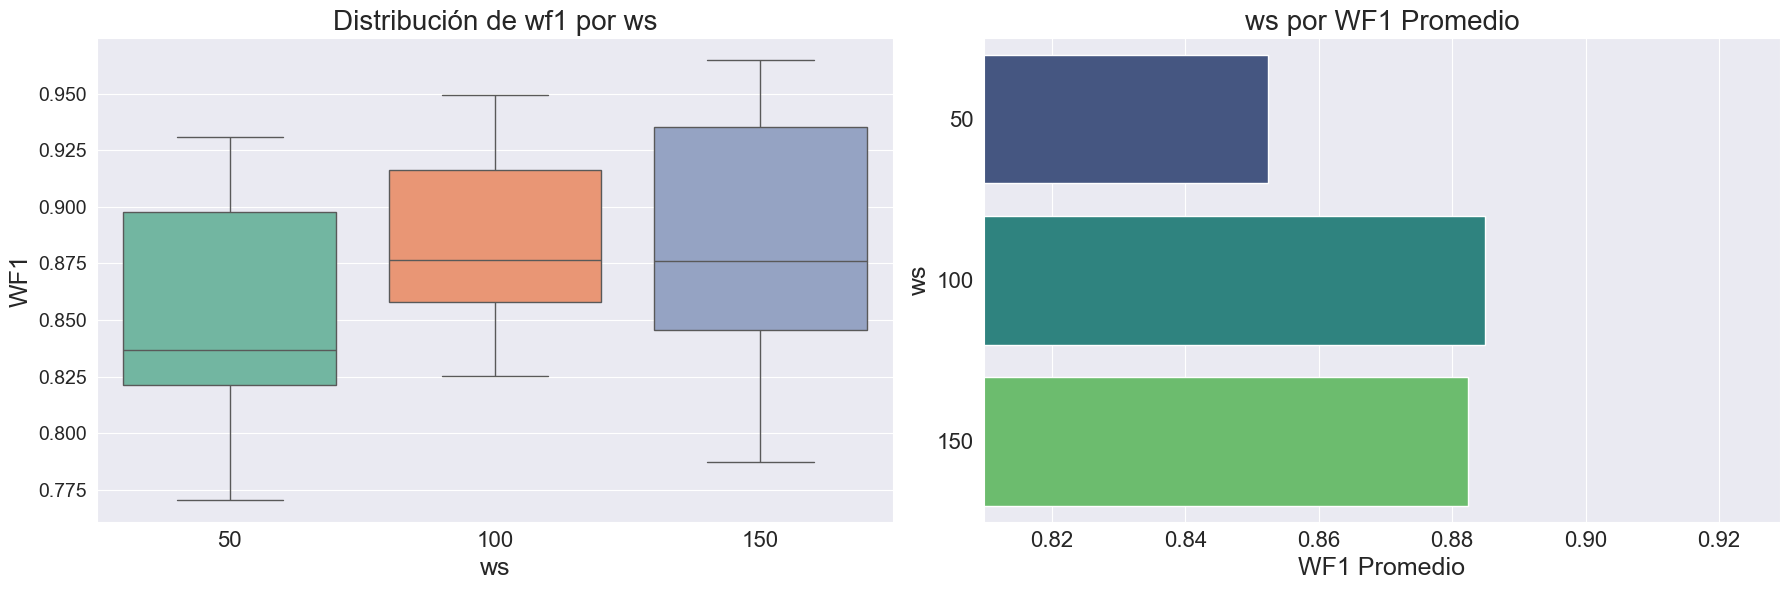

In [12]:
mann_whitney_holm('ws')

C:\Users\nathan\AppData\Local\Temp\ipykernel_27420\3857523596.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df[grupo].dtype == "object" or pd.api.types.is_categorical_dtype(df[grupo]):
C:\Users\nathan\AppData\Local\Temp\ipykernel_27420\3857523596.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fw_scores = df.groupby(grupo)["wf1"].mean().sort_values(ascending=False).reset_index()



Tabla de Resultados:
   ov 1  ov 2   P-Valor  P-valor Holm-Bonferroni  Alpha  \
0    25    50  0.270074                 0.810221   0.05   
1    25    75  0.656409                 0.905309   0.05   
2    50    75  0.452655                 0.905309   0.05   

  Diferencia Significativa  
0                       No  
1                       No  
2                       No  

Ranking de ov por WF1 Promedio:
   ov  WF1 Promedio
0  50      0.877357
1  75      0.873135
2  25      0.869197


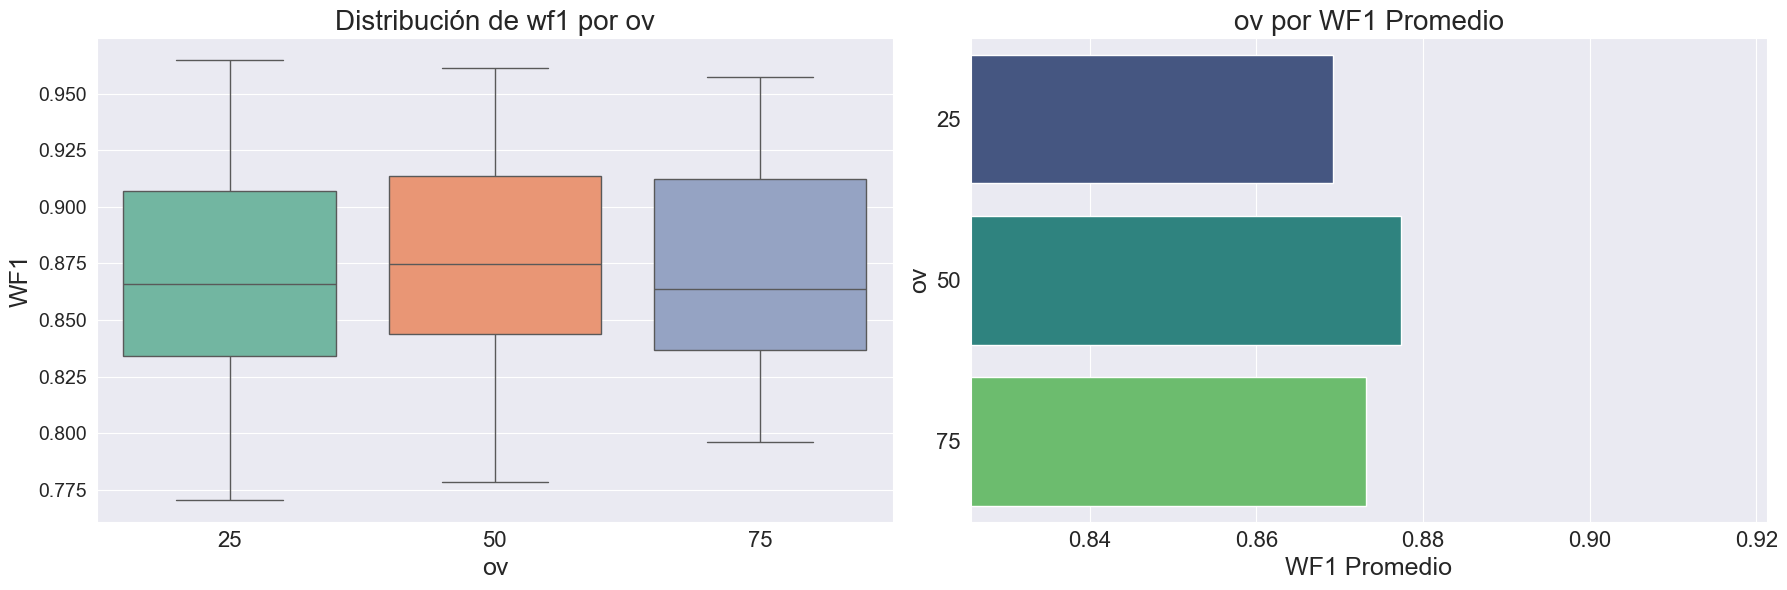

In [23]:
mann_whitney_holm('ov')

C:\Users\nathan\AppData\Local\Temp\ipykernel_31372\4176411211.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df[grupo].dtype == "object" or pd.api.types.is_categorical_dtype(df[grupo]):



Tabla de Resultados:
   dataset 1 dataset 2  Prom dataset 1  Prom dataset 2   P-Valor  \
0     100_25    100_50           0.883           0.886  0.795845   
1     100_25    100_75           0.883           0.886  0.911709   
2     100_25    150_25           0.883           0.875  0.599689   
3     100_25    150_50           0.883           0.894  0.297272   
4     100_25    150_75           0.883           0.878  0.630876   
5     100_25     50_25           0.883           0.849  0.001370   
6     100_25     50_50           0.883           0.852  0.001518   
7     100_25     50_75           0.883           0.856  0.001953   
8     100_50    100_75           0.886           0.886  0.899995   
9     100_50    150_25           0.886           0.875  0.501144   
10    100_50    150_50           0.886           0.894  0.420386   
11    100_50    150_75           0.886           0.878  0.589451   
12    100_50     50_25           0.886           0.849  0.001236   
13    100_50     50_50    

C:\Users\nathan\AppData\Local\Temp\ipykernel_31372\4176411211.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fw_scores = df.groupby(grupo)["wf1"].mean().sort_values(ascending=False).reset_index()


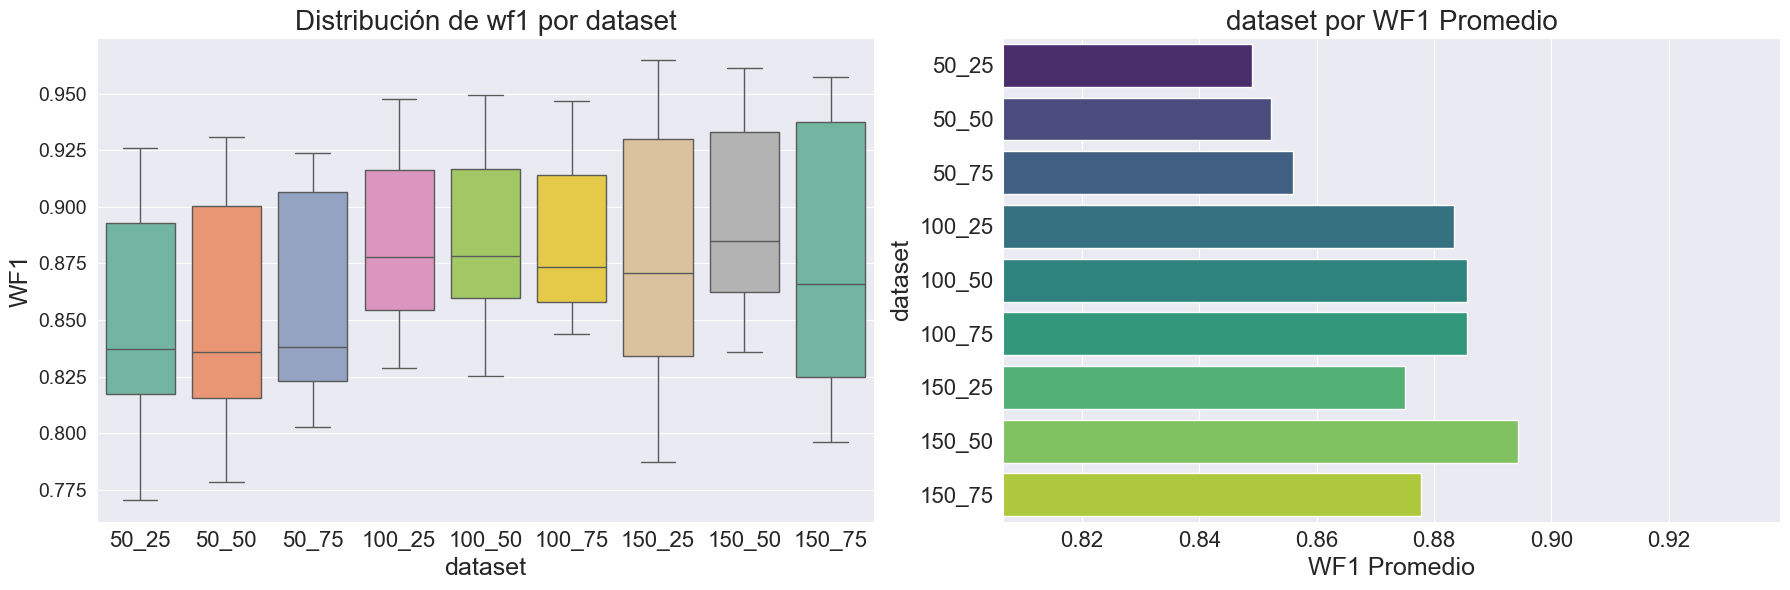

In [13]:
mann_whitney_holm('dataset')

In [29]:
# -------------------------------
# Funciones de normalidad
# -------------------------------
def test_anderson(data):
    result = anderson(data)
    return "No Normal AD" if result.statistic > result.critical_values[2] else "Normal AD"  # Nivel de significancia 5%

def test_kolmogorov_smirnov(data):
    stat, p_value = kstest(data, 'norm', args=(data.mean(), data.std()))
    return "No Normal KS" if p_value < 0.05 else "Normal KS"

def test_jarque_bera(data):
    stat, p_value = jarque_bera(data)
    return "No Normal JB" if p_value < 0.05 else "Normal JB"

# -------------------------------
# Tabla de Normalidad
# -------------------------------
def tabla_normalidad(grupo):
    """
    Genera tabla de normalidad (Anderson, KS, JB) agrupando por `grupo`
    (ej: 'ws', 'ov', 'dataset').
    """
    df = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")
    df[grupo] = df[grupo].astype("category")

    # Grupos únicos
    combinaciones = sorted(df[grupo].unique())

    # Lista para almacenar resultados
    resultados = []

    # Analizar cada combinación de sensores
    for comb in combinaciones:
        data = df[df[grupo] == comb]['wf1'].dropna()
        if not data.empty:
            mean = data.mean()
            std = data.std(ddof=1)  # Usar cuasi desviación estándar (división por n-1)
            norm_anderson = test_anderson(data)
            norm_ks = test_kolmogorov_smirnov(data)
            norm_jb = test_jarque_bera(data)
            norm = f"{norm_anderson} ({norm_ks}, {norm_jb})"
            #resultados.append([comb, round(mean, 7), round(std, 7), norm])
            resultados.append([comb, mean, std, norm])

    # Crear DataFrame con los resultados
    df_resultados = pd.DataFrame(resultados, columns=[grupo, "Promedio wf1-score", "Cuasideviación estándar del wf1-score", "Normalidad"])

    # Redondear valores numéricos
    df_resultados["Promedio wf1-score"] = df_resultados["Promedio wf1-score"].round(7)
    df_resultados["Cuasideviación estándar del wf1-score"] = df_resultados["Cuasideviación estándar del wf1-score"].round(7)

    # Mostrar la tabla
    print(f"\nTabla de Resultados para agrupación por '{grupo}':")
    print(df_resultados)

    # Visualización
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=grupo, y="wf1", hue=grupo, data=df, palette="Set2", legend=False)
    plt.title(f"Distribución de wf1 por {grupo}")
    plt.xticks(rotation=45)
    plt.savefig(f"../data/outputs/imgs/boxplot_normalidad_{grupo}.png", dpi=300)
    plt.show()


Tabla de Resultados para agrupación por 'ws':
    ws  Promedio wf1-score  Cuasideviación estándar del wf1-score  \
0   50            0.852374                               0.042338   
1  100            0.884915                               0.034170   
2  150            0.882399                               0.052061   

                                  Normalidad  
0  No Normal AD (No Normal KS, No Normal JB)  
1     No Normal AD (Normal KS, No Normal JB)  
2        No Normal AD (Normal KS, Normal JB)  


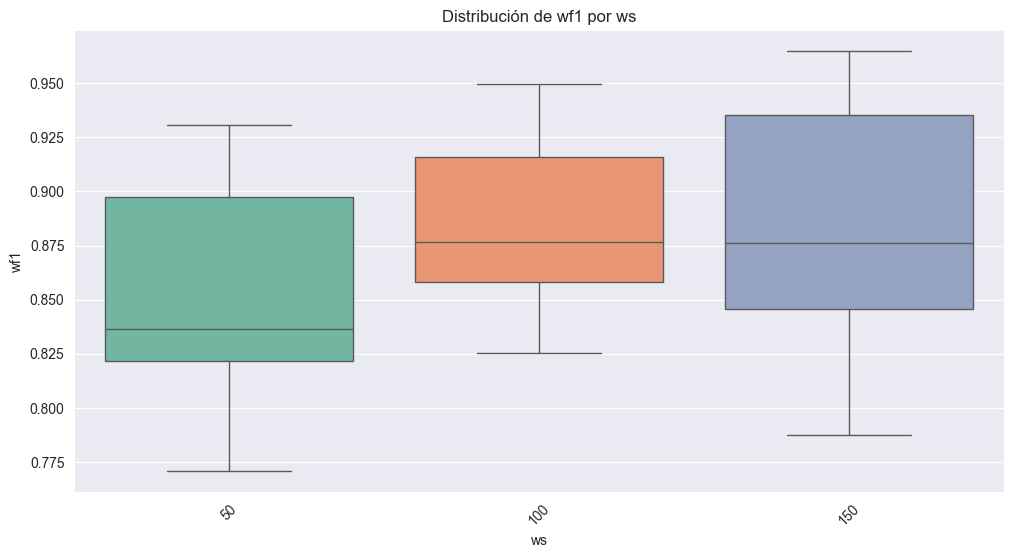

In [30]:
tabla_normalidad('ws')


Tabla de Resultados para agrupación por 'ov':
   ov  Promedio wf1-score  Cuasideviación estándar del wf1-score  \
0  25            0.869197                               0.048699   
1  50            0.877357                               0.043120   
2  75            0.873135                               0.045483   

                            Normalidad  
0     Normal AD (Normal KS, Normal JB)  
1     Normal AD (Normal KS, Normal JB)  
2  No Normal AD (Normal KS, Normal JB)  


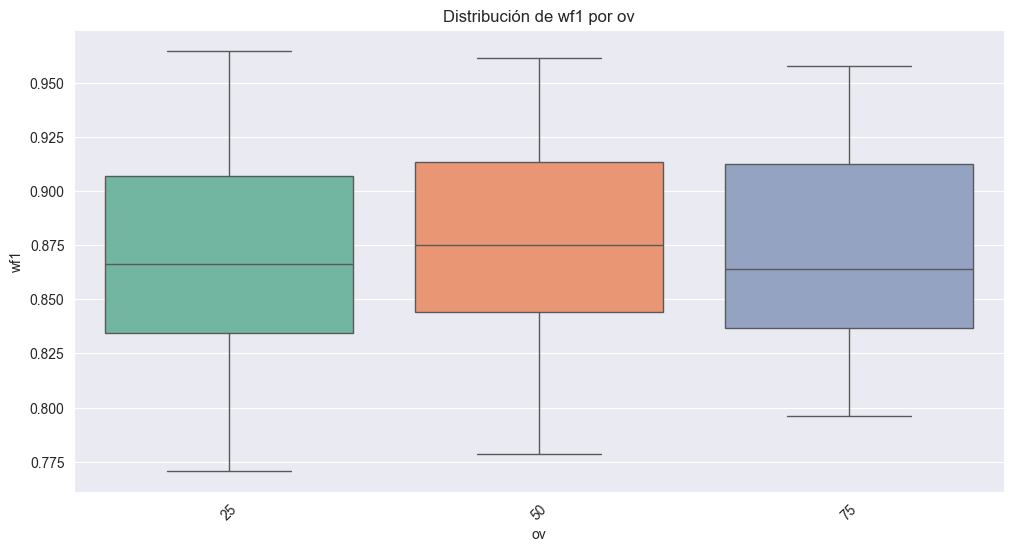

In [31]:
tabla_normalidad('ov')


Tabla de Resultados para agrupación por 'dataset':
  dataset  Promedio wf1-score  Cuasideviación estándar del wf1-score  \
0  100_25            0.883450                               0.034517   
1  100_50            0.885623                               0.034261   
2  100_75            0.885672                               0.034853   
3  150_25            0.875129                               0.059276   
4  150_50            0.894262                               0.040075   
5  150_75            0.877806                               0.054554   
6   50_25            0.849012                               0.043651   
7   50_50            0.852186                               0.043642   
8   50_75            0.855925                               0.040820   

                            Normalidad  
0     Normal AD (Normal KS, Normal JB)  
1  No Normal AD (Normal KS, Normal JB)  
2  No Normal AD (Normal KS, Normal JB)  
3     Normal AD (Normal KS, Normal JB)  
4     Normal AD (Norma

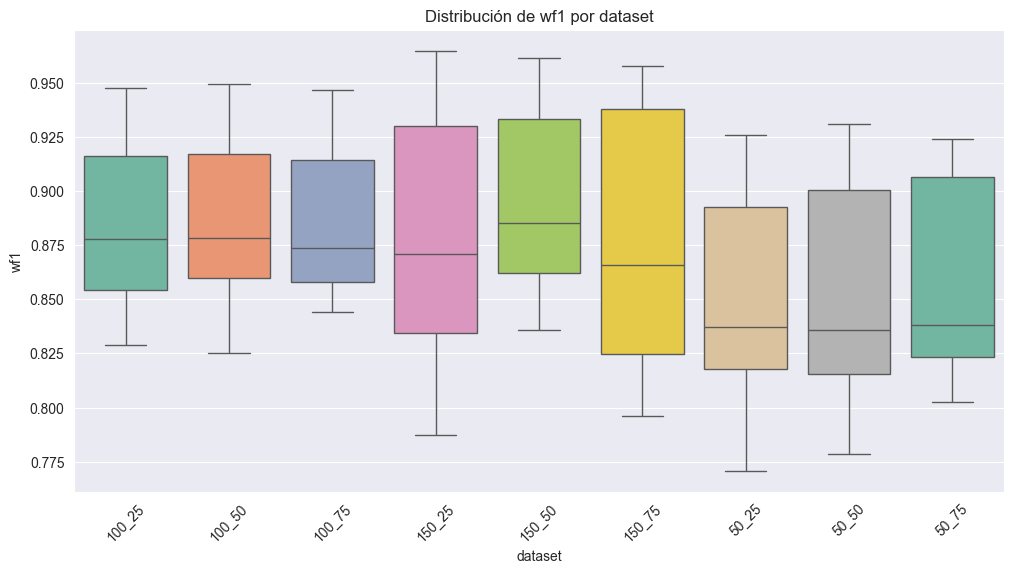

In [32]:
tabla_normalidad('dataset')

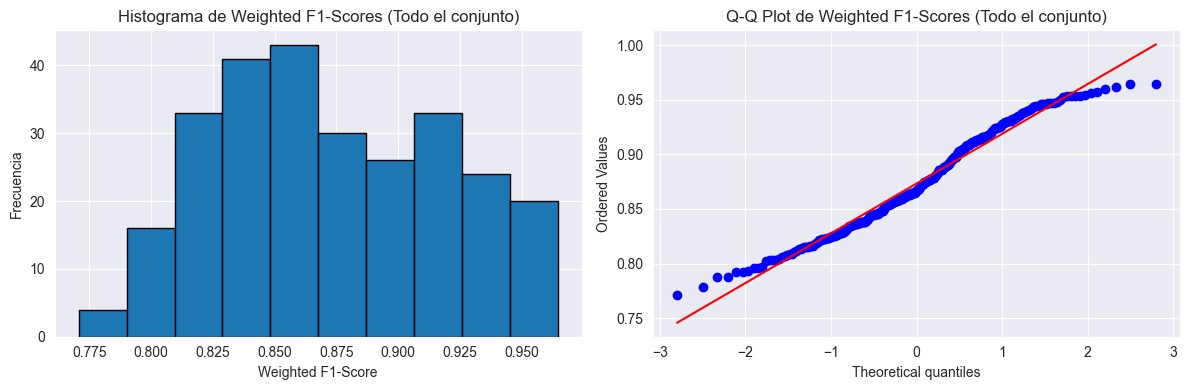


Tabla de resultados para el conjunto completo:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H0
  Anderson-Darling         1.983305                     0.776      NaN            Sí
Kolmogorov-Smirnov         0.065102                     0.134 0.193958            No
       Jarque-Bera        10.817410                     5.990 0.004477            Sí


In [34]:
#prueba normalidad
# Cargar los datos
data = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")

# Extraer los weighted f1-scores para todo el conjunto
wf1_scores_all = data['wf1']

# Realizar las pruebas para el conjunto completo
# 1. Anderson-Darling
result_ad = anderson(wf1_scores_all)
ad_statistic = result_ad.statistic
ad_critical_value = result_ad.critical_values[2]  # Valor crítico al 5% (índice 2 para ~5% con muestras pequeñas)
ad_p_value = np.nan  # Anderson-Darling no proporciona p-valor directamente
ad_reject = "Sí" if ad_statistic > ad_critical_value else "No"

# 2. Kolmogorov-Smirnov
stat_ks, p_ks = kstest(wf1_scores_all, 'norm', args=(np.mean(wf1_scores_all), np.std(wf1_scores_all)))
ks_reject = "Sí" if p_ks < 0.05 else "No"

# 3. Jarque-Bera
stat_jb, p_jb = jarque_bera(wf1_scores_all)
jb_reject = "Sí" if p_jb < 0.05 else "No"

# Crear tabla para el conjunto completo
table_all = pd.DataFrame({
    'Prueba': ['Anderson-Darling', 'Kolmogorov-Smirnov', 'Jarque-Bera'],
    'Estadístico (e)': [ad_statistic, stat_ks, stat_jb],
    'Valor crítico al 5% (vc)': [ad_critical_value, 0.134, 5.99],  # Aproximaciones; ajusta según tamaño de muestra
    'P-valor': [ad_p_value, p_ks, p_jb],
    'Rechazo de H0': [ad_reject, ks_reject, jb_reject]
})

# Visualización
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(wf1_scores_all, bins=10, edgecolor='black')
plt.title('Histograma de Weighted F1-Scores (Todo el conjunto)')
plt.xlabel('Weighted F1-Score')
plt.ylabel('Frecuencia')
plt.subplot(1, 2, 2)
stats.probplot(wf1_scores_all, dist="norm", plot=plt)
plt.title('Q-Q Plot de Weighted F1-Scores (Todo el conjunto)')
plt.tight_layout()
plt.show()

print("\nTabla de resultados para el conjunto completo:")
print(table_all.to_string(index=False))

def normalidad(grupo):
    data = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")
    # Análisis por combinación de sensores
    results_by_g = []
    for g in data[grupo].unique():
        wf1_scores_g = data[data[grupo] == g]['wf1']
        # Anderson-Darling
        result_ad_g = anderson(wf1_scores_g)
        ad_statistic_g = result_ad_g.statistic
        ad_critical_value_g = result_ad_g.critical_values[2]
        ad_p_value_g = np.nan
        ad_reject_g = "Sí" if ad_statistic_g > ad_critical_value_g else "No"
        # Kolmogorov-Smirnov
        stat_ks_g, p_ks_g = kstest(wf1_scores_g, 'norm', args=(np.mean(wf1_scores_g), np.std(wf1_scores_g)))
        ks_reject_g = "Sí" if p_ks_g < 0.05 else "No"
        # Jarque-Bera
        stat_jb_g, p_jb_g = jarque_bera(wf1_scores_g)
        jb_reject_g = "Sí" if p_jb_g < 0.05 else "No"
        # Agregar resultados
        results_by_g.append({
            'Prueba': ['Anderson-Darling', 'Kolmogorov-Smirnov', 'Jarque-Bera'],
            'Estadístico (e)': [ad_statistic_g, stat_ks_g, stat_jb_g],
            'Valor crítico al 5% (vc)': [ad_critical_value_g, 0.134, 5.99],
            'P-valor': [ad_p_value_g, p_ks_g, p_jb_g],
            'Rechazo de H0': [ad_reject_g, ks_reject_g, jb_reject_g],
            'Combinación': g
        })

    # Combinar resultados por combinación en un DataFrame
    tables_by_g = [pd.DataFrame(r) for r in results_by_g]
    for i, table in enumerate(tables_by_g):
        print(f"\nTabla de resultados para la combinación {data[grupo].unique()[i]}:")
        print(table.to_string(index=False))

In [35]:
normalidad('ws')


Tabla de resultados para la combinación 100:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H0  Combinación
  Anderson-Darling         2.288658                     0.756      NaN            Sí          100
Kolmogorov-Smirnov         0.125754                     0.134 0.106389            No          100
       Jarque-Bera         6.893460                     5.990 0.031850            Sí          100

Tabla de resultados para la combinación 150:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H0  Combinación
  Anderson-Darling         1.229656                     0.756      NaN            Sí          150
Kolmogorov-Smirnov         0.111146                     0.134 0.200628            No          150
       Jarque-Bera         4.834371                     5.990 0.089172            No          150

Tabla de resultados para la combinación 50:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo 

In [36]:
normalidad('ov')


Tabla de resultados para la combinación 25:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H0  Combinación
  Anderson-Darling         0.508133                     0.756      NaN            No           25
Kolmogorov-Smirnov         0.069940                     0.134 0.744025            No           25
       Jarque-Bera         3.242649                     5.990 0.197637            No           25

Tabla de resultados para la combinación 50:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H0  Combinación
  Anderson-Darling         0.710870                     0.756      NaN            No           50
Kolmogorov-Smirnov         0.071318                     0.134 0.722496            No           50
       Jarque-Bera         3.240974                     5.990 0.197802            No           50

Tabla de resultados para la combinación 75:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de

In [37]:
normalidad('dataset')


Tabla de resultados para la combinación 100_25:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H0 Combinación
  Anderson-Darling         0.612876                     0.712      NaN            No      100_25
Kolmogorov-Smirnov         0.130973                     0.134 0.634956            No      100_25
       Jarque-Bera         2.047513                     5.990 0.359243            No      100_25

Tabla de resultados para la combinación 100_50:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechazo de H0 Combinación
  Anderson-Darling         0.718170                     0.712      NaN            Sí      100_50
Kolmogorov-Smirnov         0.144593                     0.134 0.511212            No      100_50
       Jarque-Bera         1.851962                     5.990 0.396143            No      100_50

Tabla de resultados para la combinación 100_75:
            Prueba  Estadístico (e)  Valor crítico al 5% (vc)  P-valor Rechaz

In [40]:
def histogramas(grupo):
    data = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")

    # Crear una figura con subgráficos (3 filas x 3 columnas, ajustado para 7 combinaciones)
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()  # Aplanar el array de ejes para iterar fácilmente

    # Lista de combinaciones únicas
    combinations = data[grupo].unique()

    # Generar histograma para cada combinación
    for i, comb in enumerate(combinations):
        # Filtrar datos por combinación
        wf1_scores = data[data[grupo] == comb]['wf1']

        # Crear histograma
        axes[i].hist(wf1_scores, bins=10, edgecolor='black', density=True)
        axes[i].set_title(f'Histograma - {comb}', fontsize=20)
        axes[i].set_xlabel('Weighted F1-Score', fontsize=20)
        axes[i].set_ylabel('Densidad', fontsize=20)
        axes[i].tick_params(axis="x", labelsize=16)
        axes[i].tick_params(axis="y", labelsize=16)

        # Añadir línea de densidad (opcional, para ver la forma)
        axes[i].plot(np.linspace(min(wf1_scores), max(wf1_scores), 100),
                     stats.gaussian_kde(wf1_scores)(np.linspace(min(wf1_scores), max(wf1_scores), 100)),
                     color='red', lw=2)

    # Ocultar subgráficos no utilizados (si hay menos de 9 combinaciones)
    for j in range(len(combinations), 9):
        axes[j].axis('off')

    # Ajustar el layout
    plt.tight_layout()

    # Guardar el gráfico en la ruta especificada
    plt.savefig(f'../data/outputs/imgs/histogramas_{grupo}', dpi=300, bbox_inches='tight')
    plt.show()

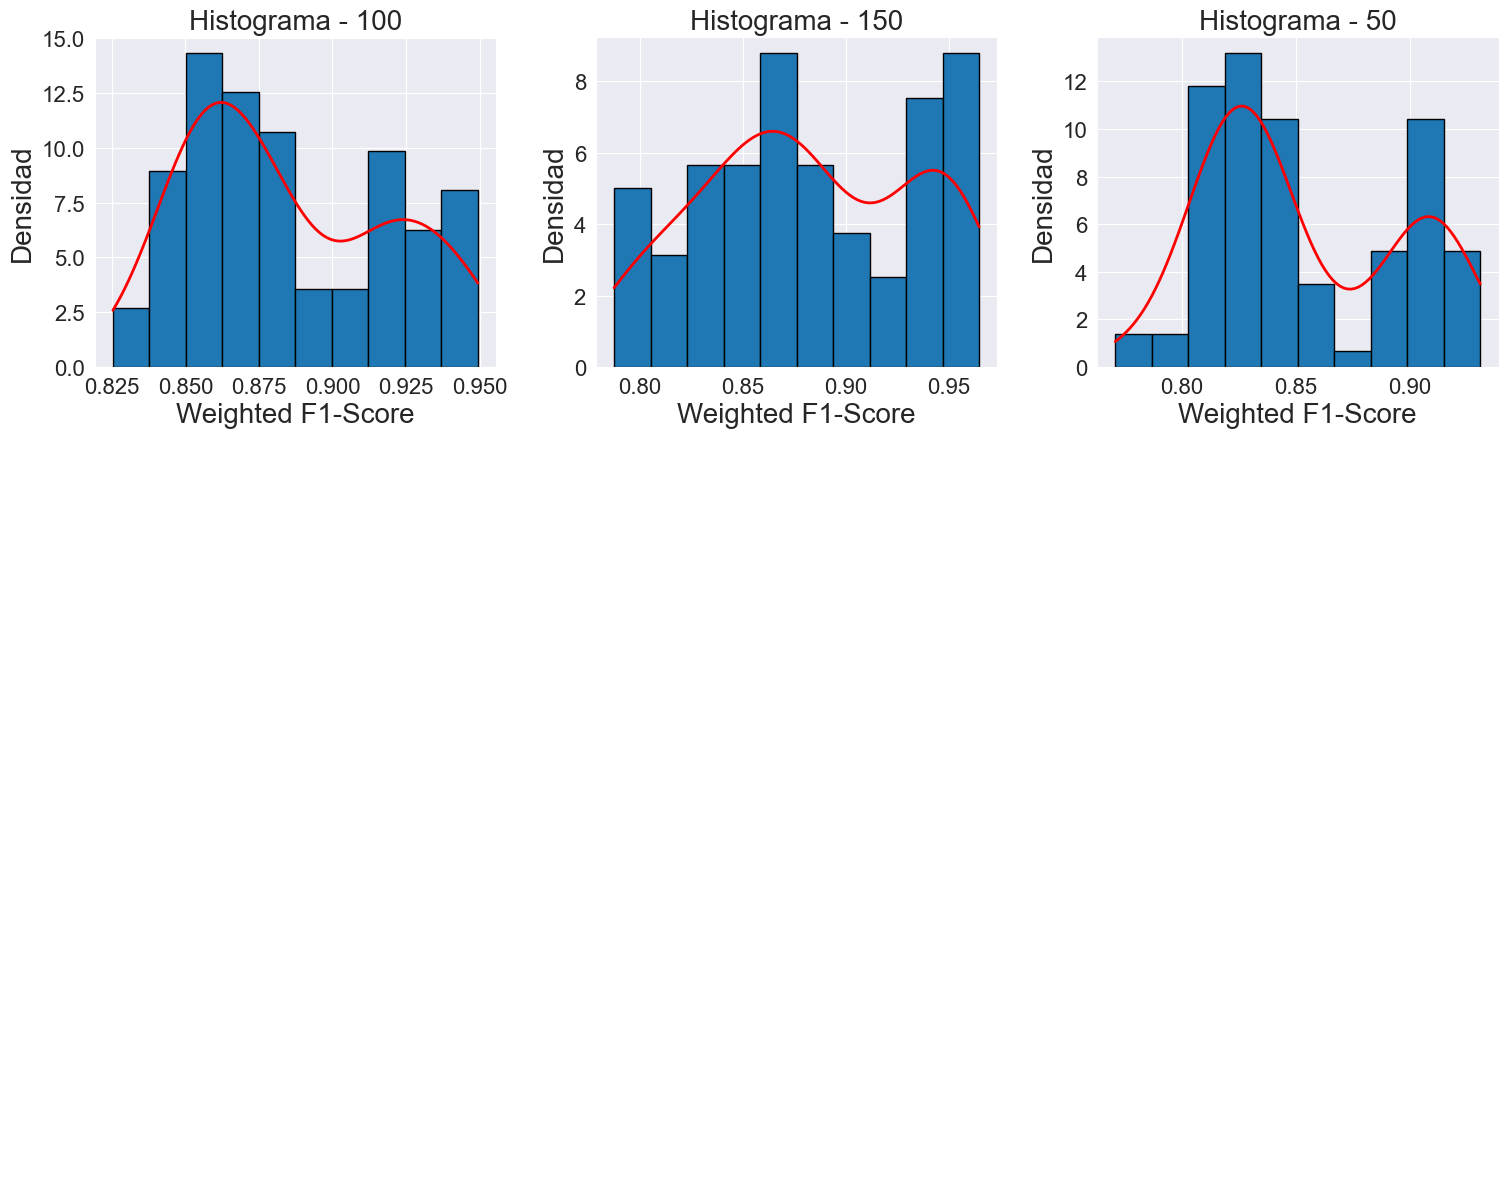

In [41]:
histogramas('ws')

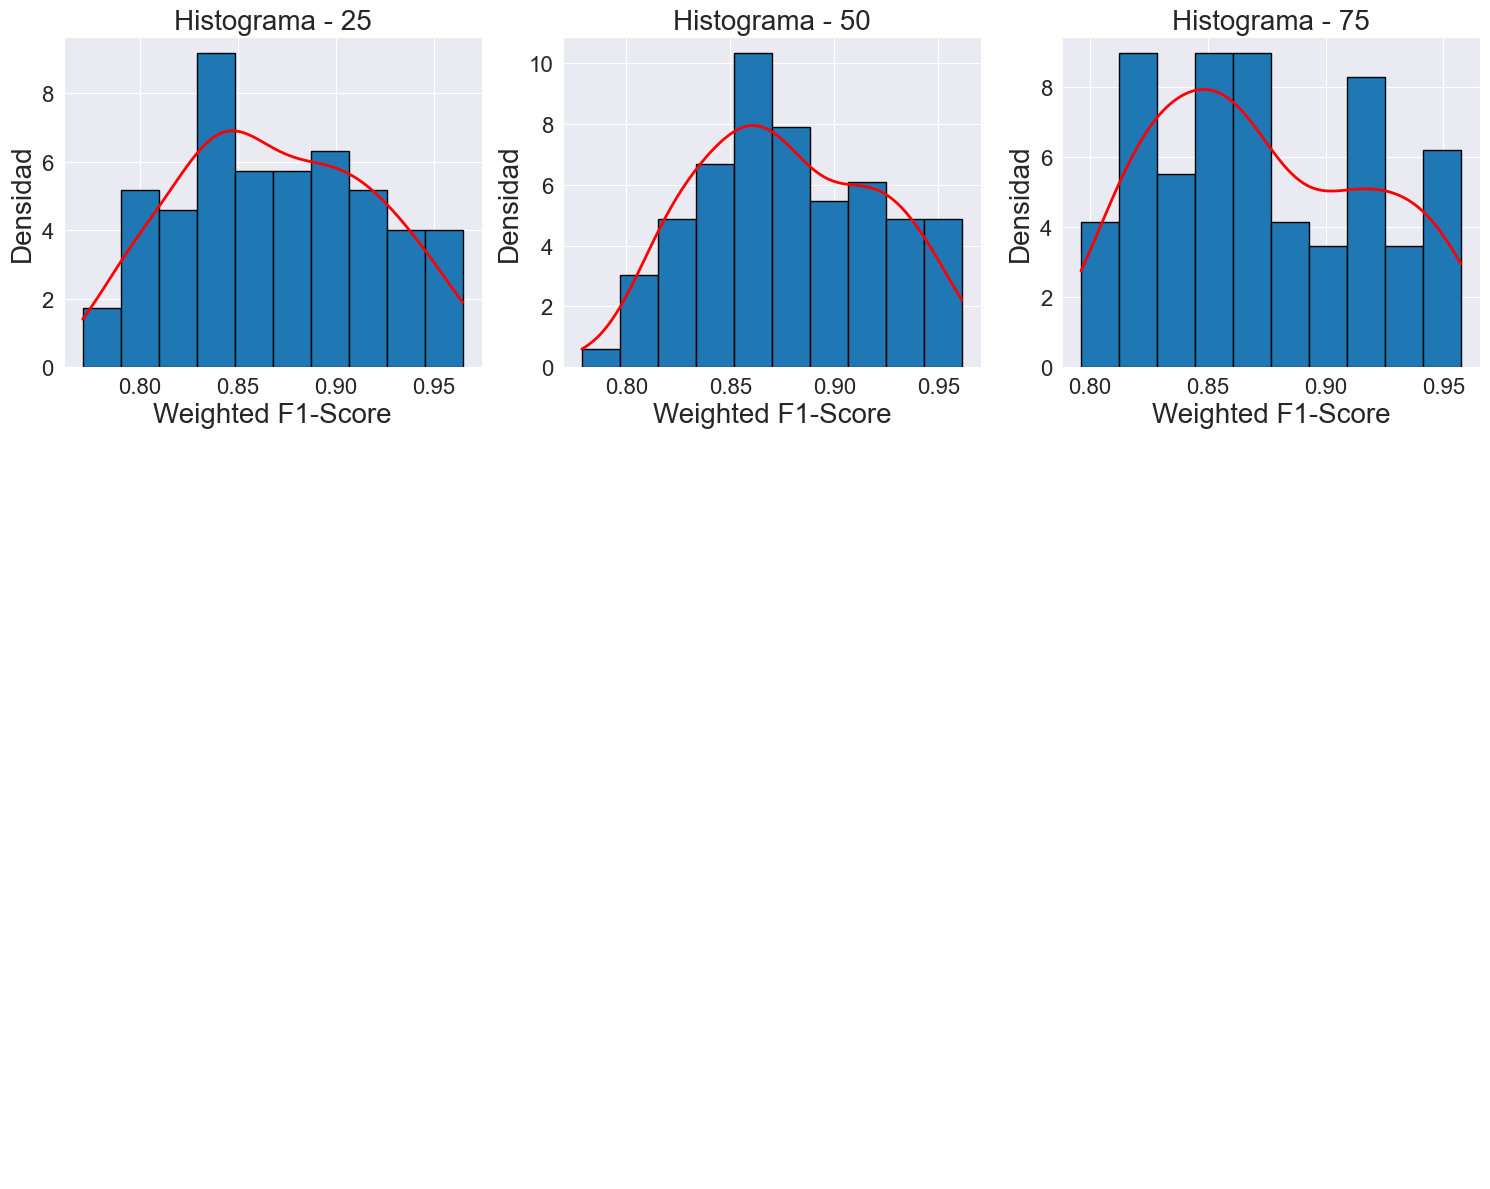

In [42]:
histogramas('ov')

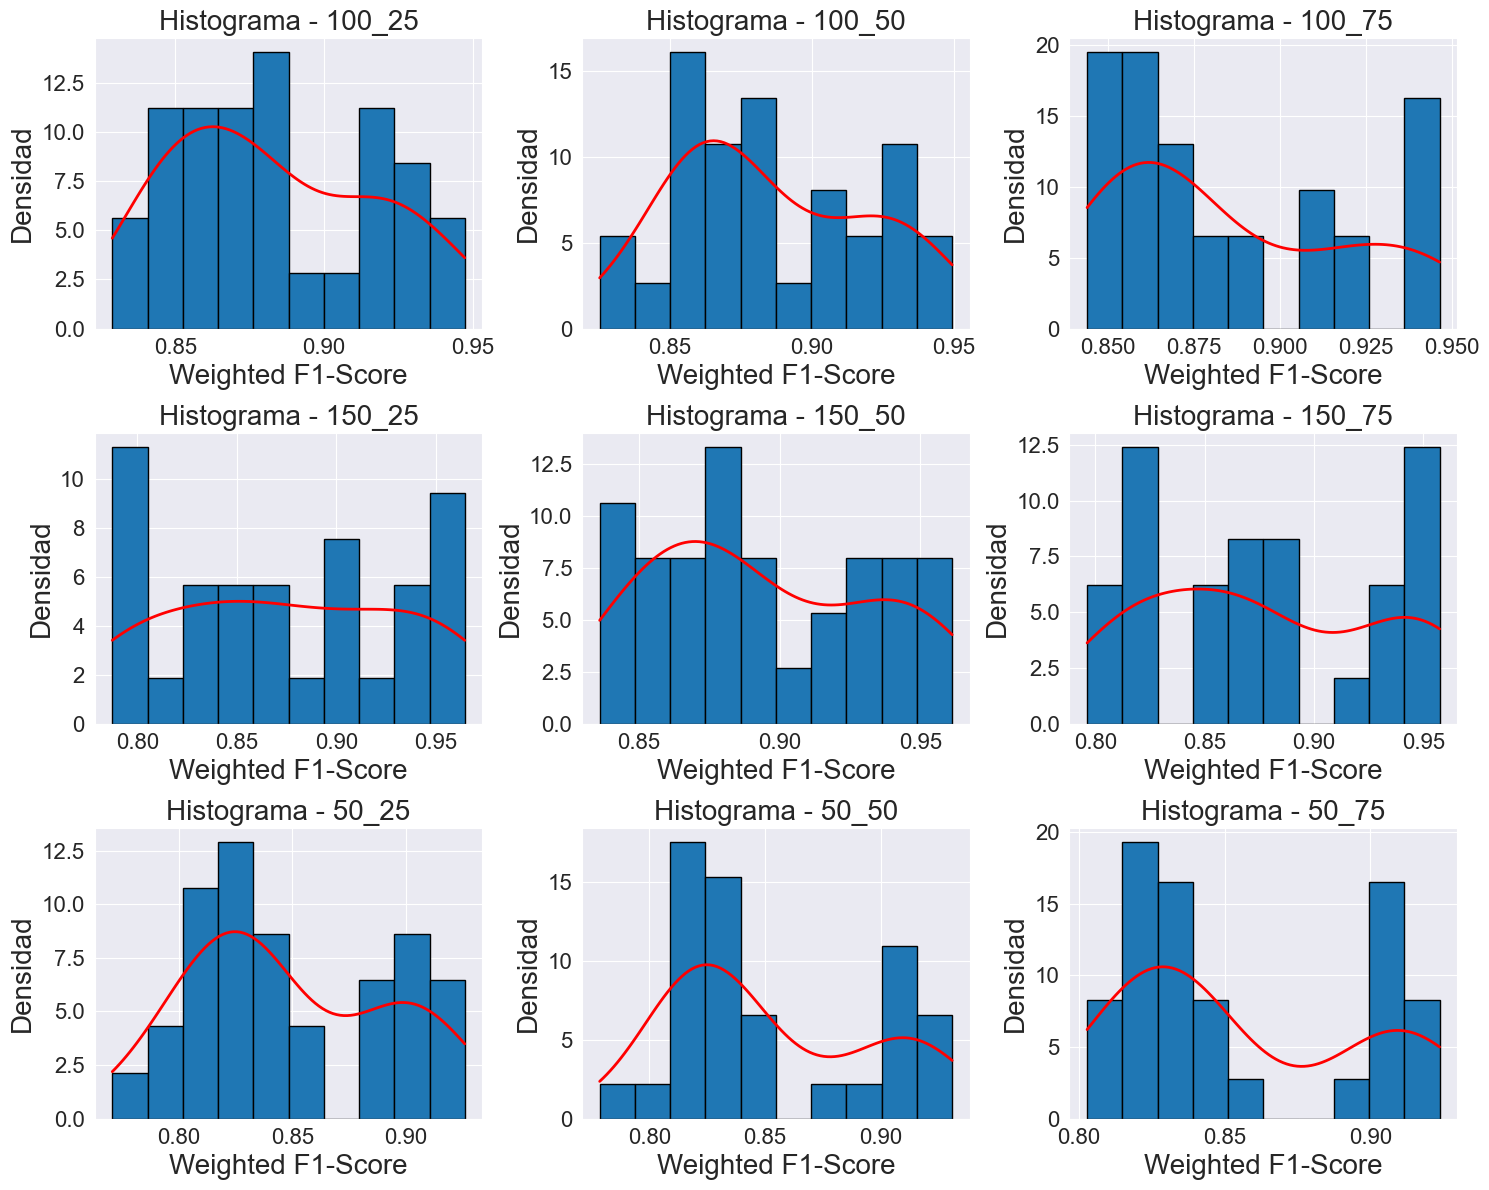

In [43]:
histogramas('dataset')

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def graficos_q_q(grupo):
    # Leer datos
    data = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")

    # Lista de combinaciones únicas y ordenarlas numéricamente si tienen formato como "50_25"
    combinations = sorted(
        data[grupo].unique(),
        key=lambda x: [int(n) for n in str(x).split('_')]
    )

    n = len(combinations)
    cols = 3
    rows = int(np.ceil(n / cols))

    # Crear figura con 3 gráficos por fila
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()

    for i, comb in enumerate(combinations):
        wf1_scores = data[data[grupo] == comb]['wf1']

        # --- Gráfico Q-Q (papel probabilístico normal) ---
        stats.probplot(wf1_scores, dist="norm", plot=axes[i])
        axes[i].set_title(f'Q–Q Plot - {comb}', fontsize=20)
        axes[i].set_xlabel('Cuantiles teóricos', fontsize=18)
        axes[i].set_ylabel('Datos ordenados', fontsize=18)

    # Desactivar ejes vacíos si hay menos gráficos que subplots
    for j in range(len(combinations), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'../data/outputs/imgs/qqplots_{grupo}.png', dpi=300, bbox_inches='tight')
    plt.show()


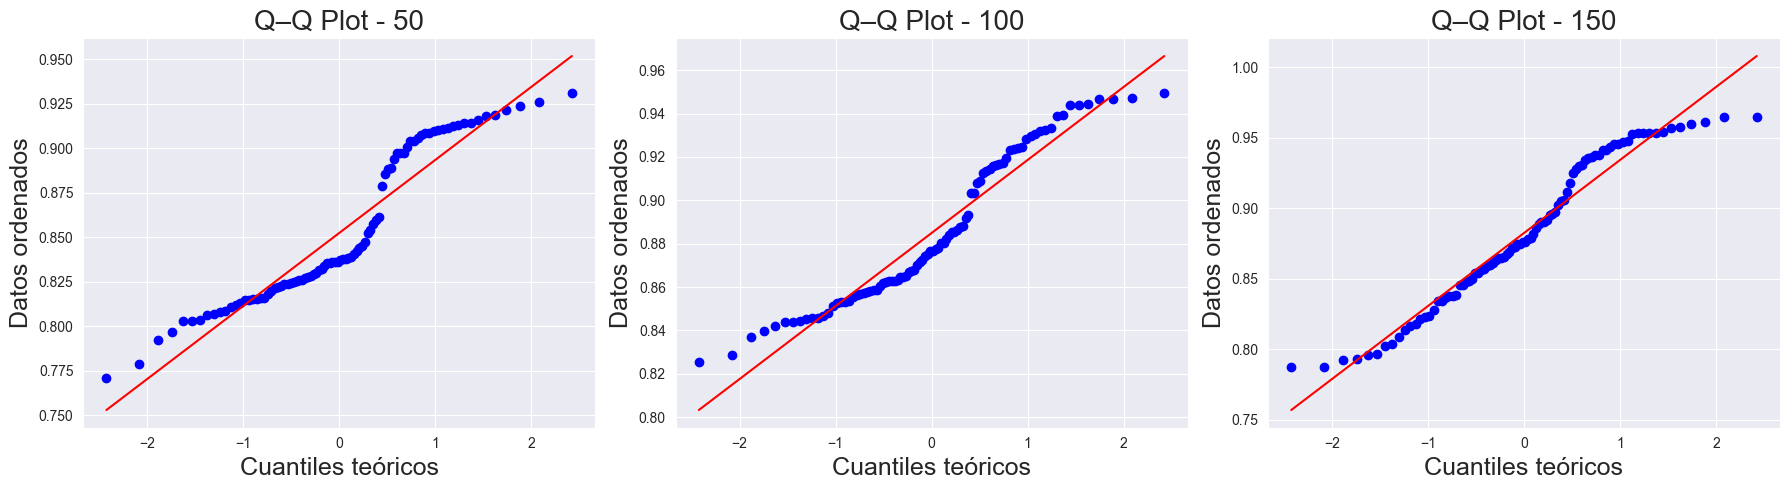

In [13]:
graficos_q_q('ws')

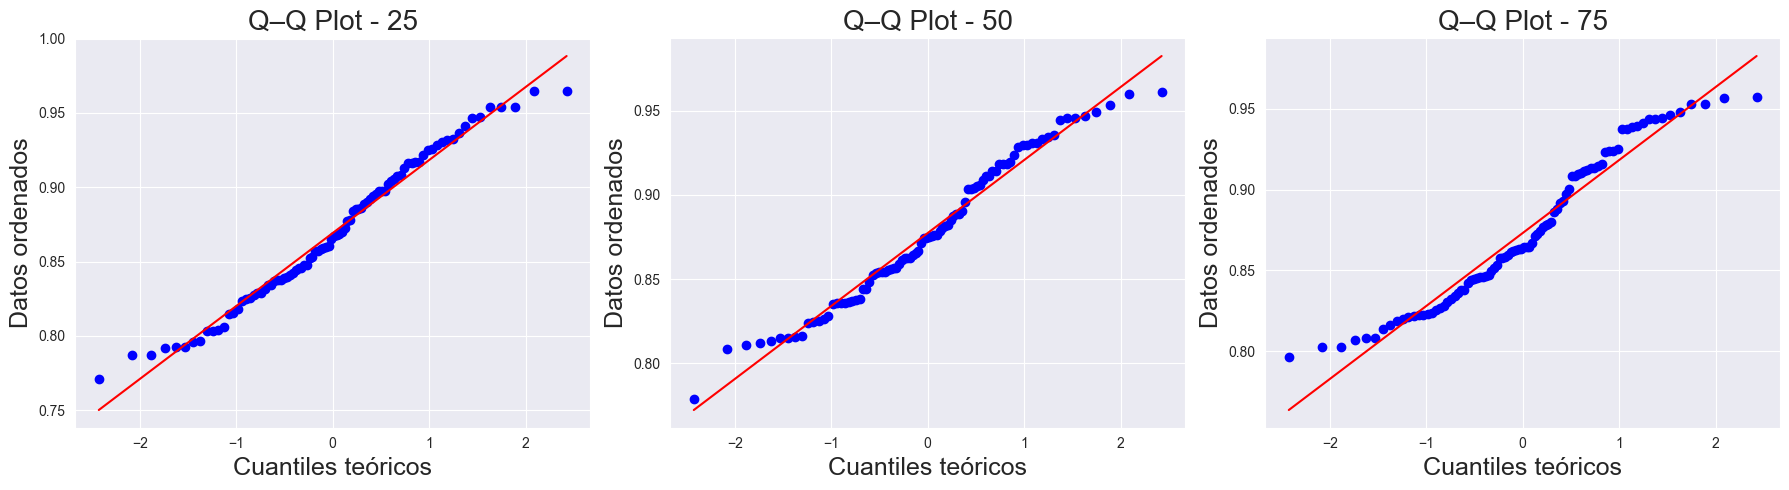

In [14]:
graficos_q_q('ov')

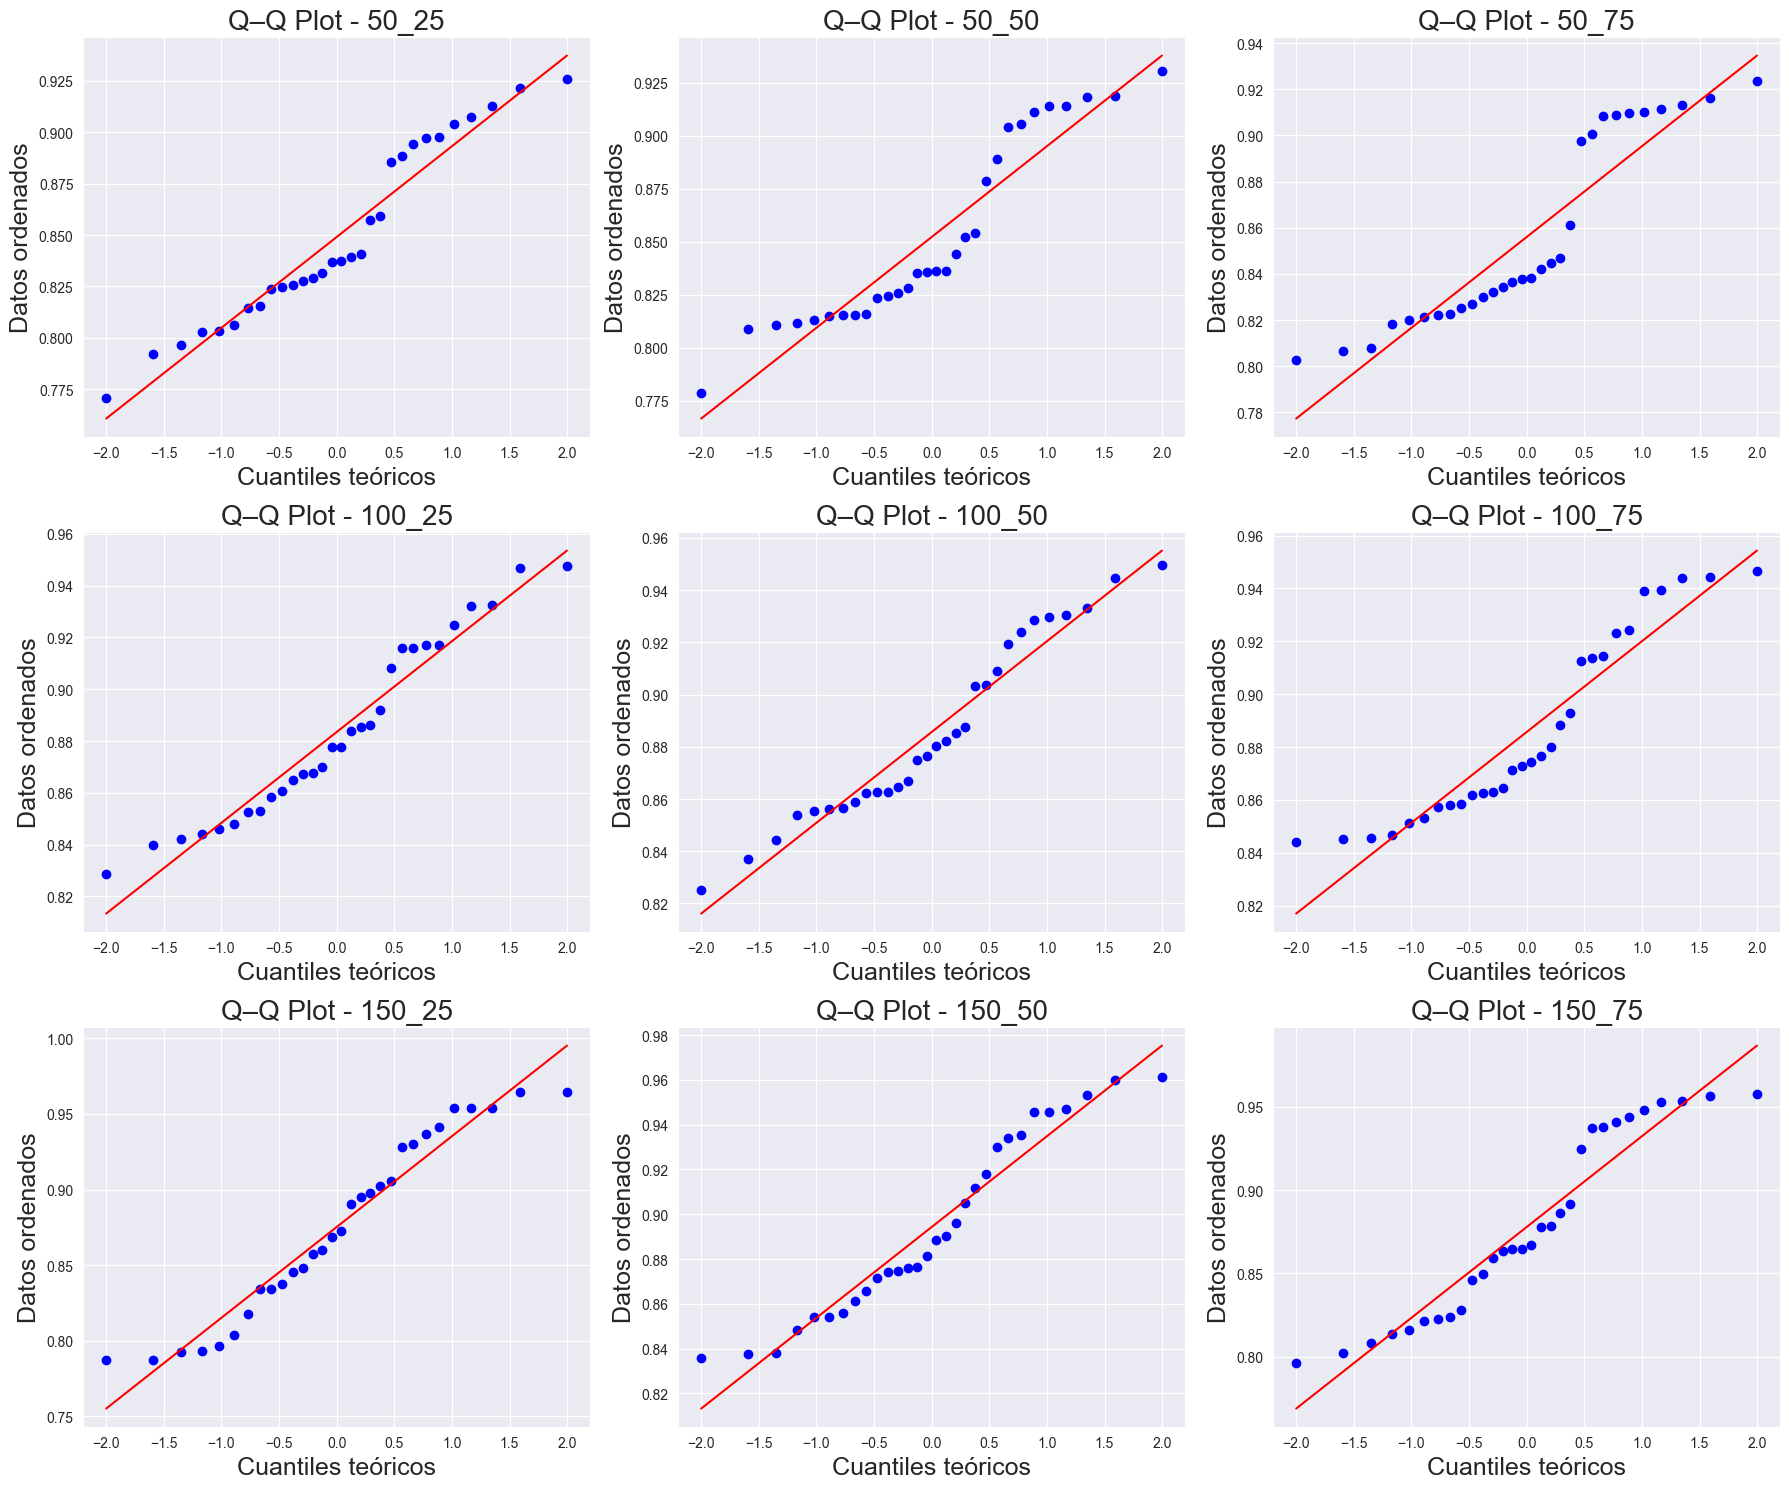

In [15]:
graficos_q_q('dataset')

In [48]:
# Función para prueba F de igualdad de varianzas entre dos grupos
def f_test(group1, group2):
    var1 = np.var(group1, ddof=1)  # Varianza muestral
    var2 = np.var(group2, ddof=1)
    if var1 > var2:
        f_stat = var1 / var2
        dfn = len(group1) - 1
        dfd = len(group2) - 1
    else:
        f_stat = var2 / var1
        dfn = len(group2) - 1
        dfd = len(group1) - 1
    p_value = 2 * (1 - f.cdf(f_stat, dfn, dfd))  # Two-tailed p-value
    return f_stat, p_value

#Igualdad de varianzas Prueba F
def varianzas_F_test(grupo):
    data = pd.read_csv("../data/outputs/analysis/Mhealth_results.csv")
    # Combinaciones únicas
    combinaciones = data[grupo].unique()

    # Lista para resultados
    resultados = []

    # Comparaciones par a par
    comparaciones = list(itertools.combinations(combinaciones, 2))

    for cat1, cat2 in comparaciones:
        grupo1 = data[data[grupo] == cat1]['wf1'].dropna()
        grupo2 = data[data[grupo] == cat2]['wf1'].dropna()
        f_stat, p_value = f_test(grupo1, grupo2)
        igualdad_varianzas = "Sí" if p_value >= 0.05 else "No"  # Igualdad si p >= 0.05
        resultados.append([cat1, cat2, round(f_stat, 4), round(p_value, 4), igualdad_varianzas])

    # Crear DataFrame con la nueva columna
    df_resultados = pd.DataFrame(resultados, columns=['Categoria 1', 'Categoria 2', 'Estadístico F', 'P-valor', 'Igualdad de Varianzas'])

    # Mostrar la tabla
    print("\nTabla de Resultados de la Prueba F (comparación de varianzas par a par):")
    print(df_resultados.to_string(index=False))

In [49]:
varianzas_F_test('ws')


Tabla de Resultados de la Prueba F (comparación de varianzas par a par):
 Categoria 1  Categoria 2  Estadístico F  P-valor Igualdad de Varianzas
         100          150         2.3213   0.0001                    No
         100           50         1.5352   0.0446                    No
         150           50         1.5120   0.0526                    Sí


In [50]:
varianzas_F_test('ov')


Tabla de Resultados de la Prueba F (comparación de varianzas par a par):
 Categoria 1  Categoria 2  Estadístico F  P-valor Igualdad de Varianzas
          25           50         1.2755   0.2529                    Sí
          25           75         1.1464   0.5205                    Sí
          50           75         1.1126   0.6158                    Sí


In [51]:
varianzas_F_test('dataset')


Tabla de Resultados de la Prueba F (comparación de varianzas par a par):
Categoria 1 Categoria 2  Estadístico F  P-valor Igualdad de Varianzas
     100_25      100_50         1.0150   0.9682                    Sí
     100_25      100_75         1.0195   0.9588                    Sí
     100_25      150_25         2.9490   0.0048                    No
     100_25      150_50         1.3479   0.4263                    Sí
     100_25      150_75         2.4979   0.0162                    No
     100_25       50_25         1.5993   0.2121                    Sí
     100_25       50_50         1.5986   0.2125                    Sí
     100_25       50_75         1.3985   0.3717                    Sí
     100_50      100_75         1.0349   0.9271                    Sí
     100_50      150_25         2.9933   0.0043                    No
     100_50      150_50         1.3682   0.4036                    Sí
     100_50      150_75         2.5355   0.0146                    No
     100_50     